# Sabarkantha District — Potato Yield Modelling with Meteorological-Week Feature Selection

**Purpose:** This notebook updates the existing Sabarkantha potato workflow so that feature selection follows the structure of the supplied reference table.

### Reference-style feature selection implemented

Instead of using only four season-average predictors (`Tmax`, `Tmin`, `RH`, `BSS`), the notebook creates **weather-parameter × Standard Meteorological Week (SMW)** features, for example:

- `BSS_12` → Bright Sunshine during SMW 12
- `RF_27` → Rainfall during SMW 27
- `WS_6` → Wind Speed during SMW 6
- `MINT_36` → Minimum Temperature during SMW 36
- `MAXT_28` → Maximum Temperature during SMW 28
- `MEAN_RH_12` → Mean Relative Humidity during SMW 12

For the existing potato workflow, the growing period remains **SMW 42–52 + SMW 1–8**.

The reference table uses three relevant selection techniques:

1. **Mutual Information** — filter method
2. **RFE** — wrapper method
3. **SelectKBest** — filter method

All three are implemented. For each regression model, the method/subset giving the best exploratory LOOCV R² is retained, producing a model-specific **Feature Selection Method** and **Selected Features** column like the reference table.

> **Important methodological note:** the supplied reference does not specify a universal fixed K or a universal model→selection-method mapping. Therefore, this notebook does **not invent one**. It tests candidate subset sizes and lets each model retain the best of the three reference-style methods. The result is an exploratory replication of the table structure, not a claim that the original study used this exact K-selection procedure.

In [1]:
# Silence the harmless scikit-learn/joblib "delayed ... should be used with Parallel" UserWarning.
# The env var is set before any parallel worker starts, so it also covers worker processes.
import os, warnings
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=r".*sklearn\.utils\.parallel\.delayed.*")

# 1. Install / import packages
# Run the installation line once if required in your environment.
# %pip install -q xgboost statsmodels openpyxl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import RFE, SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import statsmodels.api as sm
import openpyxl

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# 2. Locate / upload the Sabarkantha input files
# The notebook keeps the same file names and automatic file-detection logic as your original workflow.

YIELD_CANDIDATES = ["Gujarat_Potato_Yield_Data.csv", "Gujarat_Potato_Data.csv"]
WEATHER_CANDIDATES = ["Sabarkantha_Nasa_power.xlsx", "Sabarkantha_NASA_POWER.xlsx", "Sabarkantha_Nasa_Power.xlsx"]
SEARCH_DIRS = [".", "/content", "/mnt/user-data/uploads"]


def _find_file(candidates, search_dirs=SEARCH_DIRS):
    for d in search_dirs:
        if not os.path.isdir(d):
            continue
        for name in candidates:
            p = os.path.join(d, name)
            if os.path.isfile(p):
                return p
    for d in search_dirs:
        if not os.path.isdir(d):
            continue
        for f in os.listdir(d):
            fl = f.lower()
            for name in candidates:
                key = os.path.splitext(name)[0].lower()
                if key in fl:
                    return os.path.join(d, f)
    return None

YIELD_PATH = _find_file(YIELD_CANDIDATES)
WEATHER_PATH = _find_file(WEATHER_CANDIDATES)

if YIELD_PATH is None or WEATHER_PATH is None:
    try:
        from google.colab import files
        print("Please upload BOTH the Gujarat potato yield CSV and the Sabarkantha weather XLSX.")
        uploaded = files.upload()
        if YIELD_PATH is None:
            matches = [f for f in uploaded if f.lower().endswith(".csv")]
            YIELD_PATH = matches[0] if matches else None
        if WEATHER_PATH is None:
            matches = [f for f in uploaded if f.lower().endswith((".xlsx", ".xls"))]
            WEATHER_PATH = matches[0] if matches else None
    except ImportError:
        pass

if YIELD_PATH is None or WEATHER_PATH is None:
    raise FileNotFoundError(
        "Could not locate the input files. Set YIELD_PATH and WEATHER_PATH manually if needed."
    )

print("Yield file   :", YIELD_PATH)
print("Weather file :", WEATHER_PATH)

Yield file   : .\Gujarat_Potato_Yield_Data.csv
Weather file : .\Sabarkantha_Nasa_power.xlsx


## 3. Load and clean the yield data

The target remains **potato productivity (MT/ha)** for Sabarkantha. The long-term yield trend is removed later so that the weather models describe the residual/weather-associated component, consistent with the existing workflow.

In [3]:
DISTRICT_NAME = "Sabarkantha"


def find_col(df, candidates):
    norm = {str(c).strip().lower().replace(" ", "_"): c for c in df.columns}
    for cand in candidates:
        key = str(cand).strip().lower().replace(" ", "_")
        if key in norm:
            return norm[key]
    raise KeyError(f"None of {candidates} found. Available columns: {list(df.columns)}")


yld_full = pd.read_csv(YIELD_PATH)
yld_full.columns = [str(c).strip() for c in yld_full.columns]

district_col = find_col(yld_full, ["District", "District Name", "Dist"])
year_col = find_col(yld_full, ["Year", "Crop Year", "CropYear"])
prod_col = find_col(yld_full, ["Productivity_MT_per_ha", "Productivity", "Productivity (MT/ha)", "Yield"])

yld_raw = yld_full[
    yld_full[district_col].astype(str).str.strip().str.lower() == DISTRICT_NAME.lower()
].copy()

if yld_raw.empty:
    available = sorted(yld_full[district_col].dropna().astype(str).unique())
    raise ValueError(f"No rows found for {DISTRICT_NAME}. Available districts: {available}")

yld_raw = yld_raw[[year_col, prod_col]].rename(columns={year_col: "Year", prod_col: "Productivity"})
yld_raw["Year"] = yld_raw["Year"].astype(str).str.strip()
yld_raw = yld_raw[yld_raw["Year"].str.match(r"^\d{4}-\d{2,4}$")].copy()
yld_raw["StartYear"] = yld_raw["Year"].str[:4].astype(int)
yld_raw["Productivity"] = pd.to_numeric(yld_raw["Productivity"], errors="coerce")
yld_raw = yld_raw.dropna(subset=["Productivity"])
yld_raw = yld_raw.sort_values("StartYear").drop_duplicates("StartYear").reset_index(drop=True)

print(f"Loaded {len(yld_raw)} Sabarkantha crop-year yield records.")
display(yld_raw.head())

Loaded 31 Sabarkantha crop-year yield records.


,Year,Productivity,StartYear
0,1994-95,25.00,1994
1,1995-96,24.50,1995
2,1996-97,26.59,1996
3,1997-98,21.95,1997
4,1998-99,23.98,1998


## Objective 1 — Identify major potato-yielding districts

The complete Gujarat potato yield dataset is used to identify the major potato-yielding districts.
District-wise mean productivity (MT/ha) is calculated across the available years and districts are ranked
from highest to lowest mean productivity. This step uses the yield/productivity data only and does not
modify the original district-level dataset.


In [4]:
# Objective 1 — District-wise potato productivity ranking

district_yield = yld_full.copy()

district_yield["District"] = (
    district_yield[district_col].astype(str).str.strip()
)

district_yield["Productivity"] = pd.to_numeric(
    district_yield[prod_col], errors="coerce"
)

district_yield = district_yield[
    district_yield["District"].notna()
    & district_yield["Productivity"].notna()
    & district_yield["District"].ne("")
].copy()

district_summary = (
    district_yield
    .groupby("District", as_index=False)
    .agg(
        Mean_Productivity_MT_ha=("Productivity", "mean"),
        Median_Productivity_MT_ha=("Productivity", "median"),
        Minimum_Productivity_MT_ha=("Productivity", "min"),
        Maximum_Productivity_MT_ha=("Productivity", "max"),
        SD_Productivity_MT_ha=("Productivity", "std"),
        Number_of_Years=("Productivity", "count")
    )
    .sort_values("Mean_Productivity_MT_ha", ascending=False)
    .reset_index(drop=True)
)

district_summary.insert(0, "Rank", np.arange(1, len(district_summary) + 1))

display(district_summary)

district_summary.to_csv(
    "objective_1_gujarat_district_productivity_ranking.csv",
    index=False
)

print("Saved: objective_1_gujarat_district_productivity_ranking.csv")


,Rank,District,Mean_Productivity_MT_ha,Median_Productivity_MT_ha,Minimum_Productivity_MT_ha,Maximum_Productivity_MT_ha,SD_Productivity_MT_ha,Number_of_Years
0,1,Aravalli,33.486000,33.275,31.40,35.50,1.734456,10
1,2,Banaskantha,28.756774,29.490,22.50,32.40,2.568087,31
2,3,Sabarkantha,28.635484,30.100,17.89,34.40,5.014130,31
3,4,Gandhinagar,27.641935,27.770,18.73,36.60,4.923637,31
4,5,Devbhumi Dwarka,24.760000,27.300,0.00,28.00,8.712596,10
5,6,Mehsana,23.052258,22.000,16.00,29.98,4.803501,31
6,7,Kheda,22.114839,23.300,2.68,31.38,6.482084,31
7,8,Anand,21.964839,28.350,0.00,33.00,12.728113,31
8,9,Mahisagar,21.526000,21.060,20.00,23.65,1.259402,10
9,10,Vadodara,20.673871,21.790,0.00,26.67,6.040956,31


Saved: objective_1_gujarat_district_productivity_ranking.csv


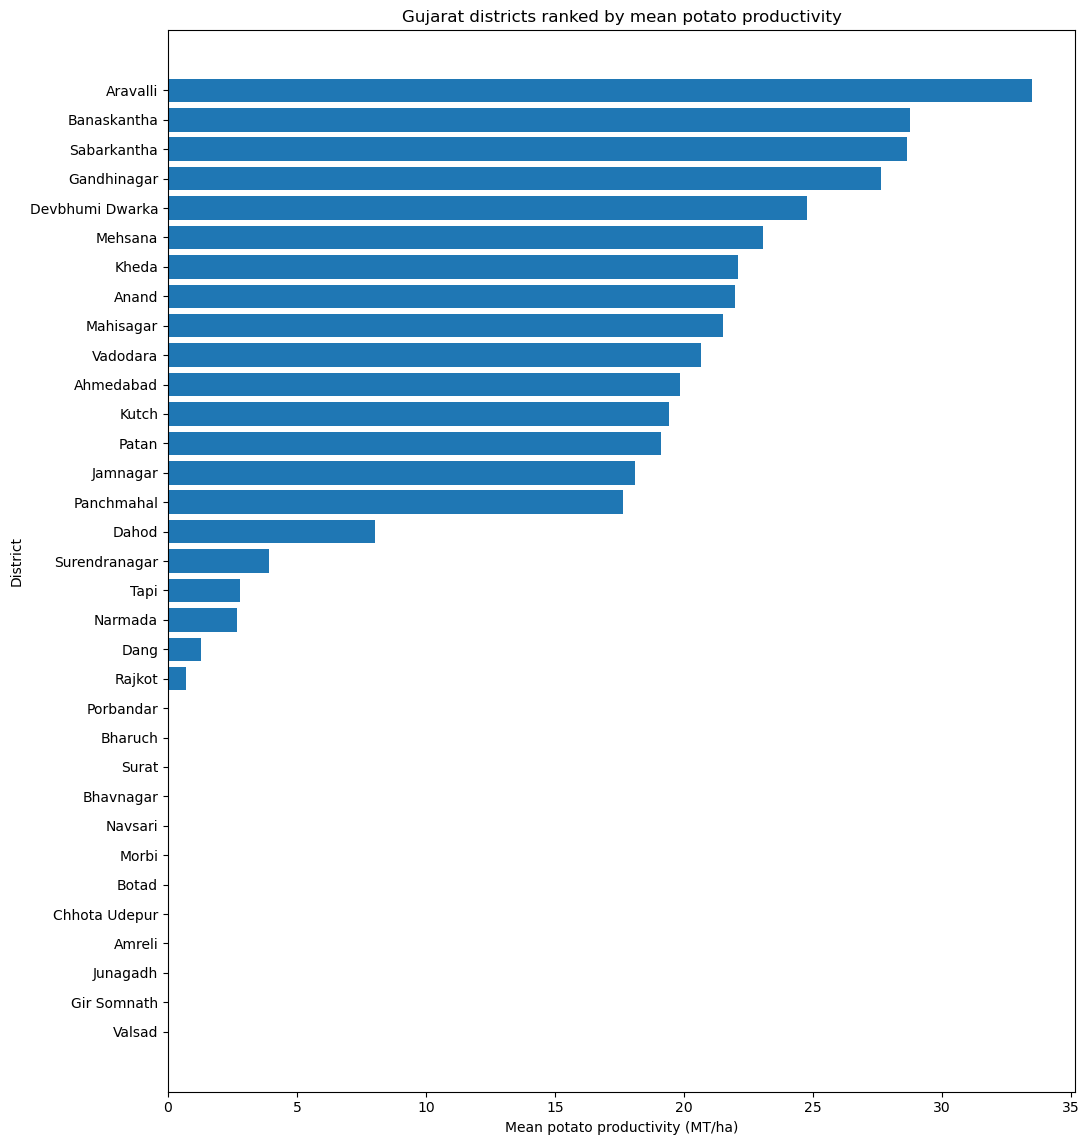

In [5]:
# Objective 1 — District-wise productivity chart

plt.figure(figsize=(11, max(6, len(district_summary) * 0.35)))

plt.barh(
    district_summary["District"],
    district_summary["Mean_Productivity_MT_ha"]
)

plt.xlabel("Mean potato productivity (MT/ha)")
plt.ylabel("District")
plt.title("Gujarat districts ranked by mean potato productivity")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## 4. Load daily weather data and identify available weather variables

The reference table contains **maximum temperature, minimum temperature, relative humidity, wind speed, bright sunshine and rainfall** when available.

The notebook therefore searches the supplied weather file for these variables. It **does not fabricate rainfall or wind speed** if they are absent. If your current NASA POWER workbook contains only Tmax/Tmin/RH/BSS, those four variables will be used and the missing variables will be clearly reported.

Weekly aggregation follows the nature of each variable:

- Tmax, Tmin, RH, WS, BSS → **weekly mean**
- RF → **weekly sum**

In [6]:
# 5. Load weather workbook and standardize variable names

wb = openpyxl.load_workbook(WEATHER_PATH, read_only=True, data_only=True)
sheet_name = wb.sheetnames[0]
ws = wb[sheet_name]
rows = list(ws.iter_rows(values_only=True))
wx_raw = pd.DataFrame(rows[1:], columns=rows[0])
wx_raw.columns = [str(c).strip() for c in wx_raw.columns]


def optional_col(df, candidates):
    norm = {str(c).strip().lower().replace(" ", "_"): c for c in df.columns}
    for cand in candidates:
        key = str(cand).strip().lower().replace(" ", "_")
        if key in norm:
            return norm[key]
    return None


date_col = find_col(wx_raw, ["Date", "DATE"])

column_candidates = {
    "MAXT": ["Max_Temp", "Max_Temperature_C", "TMAX", "Tmax", "T2M_MAX"],
    "MINT": ["Min_Temp", "Min_Temperature_C", "TMIN", "Tmin", "T2M_MIN"],
    "MEAN_RH": ["Relative_Humidity", "Relative_Humidity_percent", "RH", "RH2M", "Mean_RH"],
    "BSS": ["BSS", "Bright_Sunshine_Hours", "Bright Sunshine Hours"],
    "WS": ["WS", "Wind_Speed", "Wind Speed", "Wind_Speed_m_s", "Wind_Speed_mps", "WS10M"],
    "RF": ["RF", "Rainfall", "Rainfall_mm", "Precipitation", "Precipitation_mm", "PRECTOTCORR"]
}

selected_source_cols = {k: optional_col(wx_raw, v) for k, v in column_candidates.items()}

required = ["MAXT", "MINT", "MEAN_RH", "BSS"]
missing_required = [k for k in required if selected_source_cols[k] is None]
if missing_required:
    raise KeyError(
        f"Required weather variables not found: {missing_required}.\n"
        f"Available columns: {list(wx_raw.columns)}"
    )

print("Detected weather variables:")
for k, v in selected_source_cols.items():
    print(f"  {k:8s} -> {v}")

missing_optional = [k for k in ["WS", "RF"] if selected_source_cols[k] is None]
if missing_optional:
    print("\nWARNING: These reference-table variables are not present in the supplied workbook:", missing_optional)
    print("They will NOT be invented or estimated in this notebook.")

keep_keys = [k for k, v in selected_source_cols.items() if v is not None]
wx = wx_raw[[date_col] + [selected_source_cols[k] for k in keep_keys]].copy()
wx.columns = ["DATE"] + keep_keys
wx["DATE"] = pd.to_datetime(wx["DATE"], errors="coerce")
for c in keep_keys:
    wx[c] = pd.to_numeric(wx[c], errors="coerce")
wx = wx.dropna(subset=["DATE"]).sort_values("DATE").reset_index(drop=True)

wx["year"] = wx["DATE"].dt.year
wx["doy"] = wx["DATE"].dt.dayofyear
wx["smw"] = np.minimum(((wx["doy"] - 1) // 7) + 1, 52)

print(f"\nWeather sheet: {sheet_name}")
print(f"Weather span: {wx['DATE'].min().date()} to {wx['DATE'].max().date()} ({len(wx)} records)")

Detected weather variables:
  MAXT     -> Max_Temp
  MINT     -> Min_Temp
  MEAN_RH  -> Relative_Humidity
  BSS      -> BSS
  WS       -> WS10M
  RF       -> Precipitation

Weather sheet: Sheet1
Weather span: 1996-01-01 to 2025-12-31 (10958 records)


## 6. Construct weather × meteorological-week features

For each crop year `Y`, the potato growing season is:

- SMW 42–52 in calendar year `Y`
- SMW 1–8 in calendar year `Y+1`

Each season becomes one row. Each **weather parameter–week combination becomes a separate feature**. This is the key structural change from the previous notebook.

In [8]:
# 7. Build the weekly feature matrix

SEASON_WEEKS = list(range(42, 53)) + list(range(1, 9))

# Weekly aggregation rule: means for state/rate variables, sum for rainfall.
MEAN_VARS = [v for v in ["MAXT", "MINT", "MEAN_RH", "WS", "BSS"] if v in wx.columns]
SUM_VARS = ["RF"] if "RF" in wx.columns else []


def season_weekly_features(start_year, weather_df):
    end_year = start_year + 1
    mask = (
        ((weather_df["year"] == start_year) & weather_df["smw"].between(42, 52)) |
        ((weather_df["year"] == end_year) & weather_df["smw"].between(1, 8))
    )
    sub = weather_df.loc[mask].copy()

    out = {"StartYear": start_year, "n_days": len(sub)}
    observed_weeks = set(sub["smw"].dropna().astype(int).unique())
    out["n_weeks_observed"] = len(observed_weeks)

    for var in MEAN_VARS:
        for week in SEASON_WEEKS:
            vals = sub.loc[sub["smw"] == week, var]
            out[f"{var}_{week}"] = vals.mean() if len(vals) else np.nan

    for var in SUM_VARS:
        for week in SEASON_WEEKS:
            vals = sub.loc[sub["smw"] == week, var]
            out[f"{var}_{week}"] = vals.sum(min_count=1) if len(vals) else np.nan

    return out


wx_min_year, wx_max_year = int(wx["year"].min()), int(wx["year"].max())

usable_years = [
    sy for sy in yld_raw["StartYear"]
    if sy >= wx_min_year and sy + 1 <= wx_max_year
]

rows = [season_weekly_features(sy, wx) for sy in usable_years]
weekly_weather = pd.DataFrame(rows)

# Merge with yield.
data = yld_raw.merge(weekly_weather, on="StartYear", how="inner").sort_values("StartYear").reset_index(drop=True)
data["CropYear"] = data["Year"]

if data.empty:
    raise ValueError("No yield seasons overlap the available weather period.")

# A complete growing season must contain all 19 target SMWs and a reasonable number of daily records.
data = data[(data["n_weeks_observed"] == len(SEASON_WEEKS)) & data["n_days"].between(125, 145)].copy()
data = data.reset_index(drop=True)

if len(data) < 5:
    raise ValueError(
        f"Only {len(data)} complete seasons remain. Check the weather coverage before modelling."
    )

# All weather × week columns.
WEEKLY_FEATURES = [
    c for c in data.columns
    if any(c.startswith(v + "_") for v in ["MAXT", "MINT", "MEAN_RH", "WS", "BSS"])
]

print(f"Complete seasons retained: {len(data)}")
print(f"Weekly weather features created: {len(WEEKLY_FEATURES)}")
print("Feature groups:", sorted(set(c.rsplit("_", 1)[0] for c in WEEKLY_FEATURES)))

display(data[["CropYear", "StartYear", "Productivity", "n_days", "n_weeks_observed"]])

Complete seasons retained: 29
Weekly weather features created: 95
Feature groups: ['BSS', 'MAXT', 'MEAN_RH', 'MINT', 'WS']


,CropYear,StartYear,Productivity,n_days,n_weeks_observed
0,1996-97,1996,26.59,135,19
1,1997-98,1997,21.95,134,19
2,1998-99,1998,23.98,134,19
3,1999-00,1999,18.00,134,19
4,2000-01,2000,23.97,135,19
5,2001-02,2001,22.08,134,19
6,2002-03,2002,17.89,134,19
7,2003-04,2003,25.00,134,19
8,2004-05,2004,29.00,135,19
9,2005-06,2005,22.00,134,19


In [8]:
# 8. Export the complete weather × SMW feature table

season_features_path = "season_weekly_features_sabarkantha.csv"
data.to_csv(season_features_path, index=False)

print(f"Saved: {season_features_path}")
print(f"Rows: {len(data)} | Weekly weather predictors: {len(WEEKLY_FEATURES)}")

Saved: season_weekly_features_sabarkantha.csv
Rows: 29 | Weekly weather predictors: 114


## Objectives 2–4 — Weather–yield correlation, influential weeks and crop-growth-stage sensitivity

These analyses are separate from the existing machine-learning feature-selection workflow.
Pearson correlation measures linear association and Spearman correlation measures monotonic association.
Benjamini–Hochberg false-discovery-rate (FDR) correction is applied to the multiple statistical tests.

The weekly analysis covers SMW 42–52 and SMW 1–8, consistent with the existing potato growing-season definition.
The growth-stage mapping is an explicit analytical framework; it should be adjusted if the final agronomic
reference or actual planting dates used in the study support different phenological boundaries.


In [9]:
# Objectives 2–4 — Robust weather–yield correlation analysis

from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

BASE_WEATHER_VARS = ["MAXT", "MINT", "MEAN_RH", "WS", "BSS"]
AVAILABLE_WEATHER_VARS = [
    v for v in BASE_WEATHER_VARS
    if any(c.startswith(v + "_") for c in WEEKLY_FEATURES)
]

if not AVAILABLE_WEATHER_VARS:
    raise ValueError("No weekly weather variables are available for correlation analysis.")

def _safe_correlations(x, y):
    temp = pd.DataFrame({"x": x, "y": y}).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()

    n = len(temp)

    if n < 3 or temp["x"].nunique() < 2 or temp["y"].nunique() < 2:
        return n, np.nan, np.nan, np.nan, np.nan

    r, p = pearsonr(temp["x"], temp["y"])
    rho, sp = spearmanr(temp["x"], temp["y"])
    return n, r, p, rho, sp


## 7. Detrend potato productivity

The existing workflow is retained: a linear time trend is fitted to productivity and the residual is used as the weather-associated target.

`Yield_detrended = Observed Productivity − Fitted Time Trend`

Trend equation: Productivity = 0.5133 × time + 21.7170
Trend R²: 0.741


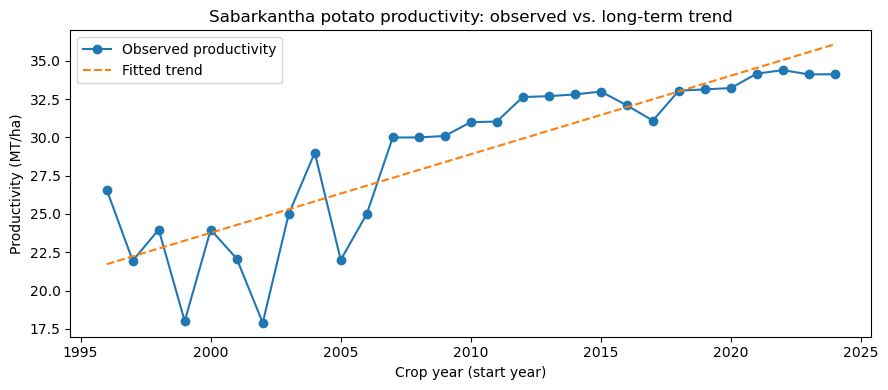

In [10]:
# 9. Fit the long-term productivity trend and create the detrended target

y = data["Productivity"].reset_index(drop=True)
t = np.arange(len(data)).reshape(-1, 1)

trend_model = LinearRegression().fit(t, y)
trend = trend_model.predict(t)
y_detrended = y - trend

data["Trend"] = trend
data["Yield_detrended"] = y_detrended

print(f"Trend equation: Productivity = {trend_model.coef_[0]:.4f} × time + {trend_model.intercept_:.4f}")
print(f"Trend R²: {trend_model.score(t, y):.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(data["StartYear"], y, "o-", label="Observed productivity")
ax.plot(data["StartYear"], trend, "--", label="Fitted trend")
ax.set_xlabel("Crop year (start year)")
ax.set_ylabel("Productivity (MT/ha)")
ax.set_title("Sabarkantha potato productivity: observed vs. long-term trend")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Model-specific reference-style feature selection

The previous version had an important flaw: it created **one global selected feature set per method**, and then every model reused that same set. It also allowed `K=1`, which is why all models could collapse to one feature such as `MEAN_RH_48`.

This version fixes that design:

1. **Each model is evaluated independently.**
2. For each model, **Mutual Information, RFE and SelectKBest are evaluated separately**.
3. Several candidate feature counts are tested (`K=3` to a conservative maximum).
4. The RFE estimator is chosen to be compatible with the model family where possible, instead of always using Random Forest.
5. The selected feature set is therefore allowed to differ by **model + method + K**.
6. The final table reports the selected parameter-week features, e.g. `MINT_36`, `WS_6`, etc.

### Important
The supplied reference image does **not** specify the original study's exact K values or its exact model-to-feature-selection mapping. Therefore, no exact mapping can be recovered from the image alone. The notebook reproduces the **feature-selection structure**, while using an explicit and transparent Sabarkantha-specific K range.

Because only a small number of complete seasons are available, this remains exploratory rather than confirmatory.


In [11]:
# 10. Feature-selection helper functions  (LEAKAGE-FREE / NESTED VERSION)

# Raw modelling matrix. NOTE: no imputation and no selection happen here any more.
# Median imputation, feature selection and model fitting are all done INSIDE each LOOCV
# fold, using only that fold's training seasons (see the nested-LOOCV cell below).
X_raw = data[WEEKLY_FEATURES].replace([np.inf, -np.inf], np.nan).copy().reset_index(drop=True)
target = data["Yield_detrended"].copy().reset_index(drop=True)

SELECTION_METHODS = ["Mutual Information", "RFE", "SelectKBest"]

# The reference table never shows a single-feature final set. With only a small
# number of Sabarkantha seasons, use a conservative lower bound of 3 features.
MIN_K = 3
MAX_K = min(8, len(data) - 3, len(WEEKLY_FEATURES))
K_VALUES = list(range(MIN_K, MAX_K + 1))

if not K_VALUES:
    raise ValueError("Not enough seasons to test the requested minimum feature count.")


def impute_train_median(X_train, *others):
    """Fill NaNs using the median of the TRAINING rows only; apply the same values to any other frames."""
    med = X_train.median(numeric_only=True)
    out = [X_train.fillna(med).fillna(0.0)]
    for X in others:
        out.append(X.fillna(med).fillna(0.0))
    return out if others else out[0]


def select_mi(X, y_target, k):
    mi = mutual_info_regression(X, y_target, random_state=RANDOM_STATE)
    scores = np.nan_to_num(mi, nan=-np.inf)
    idx = np.argsort(scores)[::-1][:k]
    return list(X.columns[idx]), scores


def select_kbest(X, y_target, k):
    skb = SelectKBest(score_func=f_regression, k=k).fit(X, y_target)
    scores = np.nan_to_num(skb.scores_, nan=-np.inf)
    idx = np.argsort(scores)[::-1][:k]
    return list(X.columns[idx]), scores


def rfe_estimator_for_model(model_name):
    # RFE requires an estimator exposing coef_ or feature_importances_.
    # Where the downstream model supports feature importance directly, use it.
    if model_name == "Random Forest":
        return RandomForestRegressor(
            n_estimators=150, max_depth=4, random_state=RANDOM_STATE, n_jobs=-1
        )
    if model_name == "XGBoost":
        return XGBRegressor(
            n_estimators=120, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, verbosity=0
        )
    # Linear proxy for models without native RFE-compatible importance.
    return LinearRegression()


def select_rfe(X, y_target, k, model_name):
    estimator = rfe_estimator_for_model(model_name)
    rfe = RFE(estimator=estimator, n_features_to_select=k, step=0.2)
    rfe.fit(X, y_target)
    return list(X.columns[rfe.support_]), rfe.ranking_


def r2_rmse_mae(y_true, preds):
    y_true = np.asarray(y_true, dtype=float)
    preds = np.asarray(preds, dtype=float)
    ss_res = np.sum((y_true - preds) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return r2, np.sqrt(ss_res / len(y_true)), np.mean(np.abs(y_true - preds))

print(f"Complete seasons: {len(data)}")
print(f"Candidate weather × SMW predictors: {len(WEEKLY_FEATURES)}")
print(f"Candidate K values per model/method: {K_VALUES}")


Complete seasons: 29
Candidate weather × SMW predictors: 95
Candidate K values per model/method: [3, 4, 5, 6, 7, 8]


## 9. Why the previous version produced the same `MEAN_RH_48` + RFE result

The previous code did this: **select features once globally → reuse those features for every model**. In particular, `select_rfe()` always used a Random Forest estimator, regardless of whether the downstream model was XGBoost, ANN, SVR, KNN or Random Forest.

It also selected the best K using a linear-regression screen before the model comparison. Because the dataset is very small, that screen could prefer `K=1`.

The corrected code below instead performs the method/K search **inside each model loop**. Therefore the selected features are no longer forced to be identical across models.


---

### Leakage fix (nested LOOCV)

The earlier corrected version still chose the weeks (and filled missing values) **once on all seasons** and only then ran LOOCV, so every held-out season had already influenced which weeks were selected. With ~25 seasons and over 100 candidate weekly features, this can make almost any feature set look predictive.

Now, for **every LOOCV fold**: median imputation, Mutual Information / RFE / SelectKBest selection and model fitting use **only that fold's training seasons**. The reported R², RMSE and MAE come entirely from these out-of-sample predictions. A full-data selection is still computed once, but only to display the final feature list and to refit the production model.


In [12]:
# 11. Build model-specific feature-selection candidates (usable on ANY training subset)

# RFE only depends on the estimator family, so models that share an RFE estimator share the result.
RFE_REPRESENTATIVE = {"Random Forest": "Random Forest", "XGBoost": "XGBoost"}   # everything else -> linear proxy


def selection_candidates(X_train, y_train, model_names):
    """Return {(model, method, k): [feature names]} using ONLY the rows passed in.

    Called (a) once per LOOCV fold with that fold's training seasons only, and
    (b) once on the full dataset, purely to display / refit the final production model.
    X_train must already be imputed (see impute_train_median)."""
    kmax = max(K_VALUES)
    mi_order = select_mi(X_train, y_train, kmax)[0]
    kb_order = select_kbest(X_train, y_train, kmax)[0]
    rfe_cache = {}
    out = {}
    for m in model_names:
        rkey = RFE_REPRESENTATIVE.get(m, "linear")
        for k in K_VALUES:
            out[(m, "Mutual Information", k)] = mi_order[:k]
            out[(m, "SelectKBest", k)] = kb_order[:k]
            if (rkey, k) not in rfe_cache:
                rfe_cache[(rkey, k)] = select_rfe(X_train, y_train, k, m)[0]
            out[(m, "RFE", k)] = rfe_cache[(rkey, k)]
    return out

print("Feature-selection functions ready (training-subset aware).")


Feature-selection functions ready (training-subset aware).


In [13]:
# 12. Define the downstream regression models

def make_model(name):
    if name == "Stepwise Linear Regression":
        return lambda: LinearRegression()
    if name == "Random Forest":
        return lambda: RandomForestRegressor(
            n_estimators=300, max_depth=4, random_state=RANDOM_STATE, n_jobs=-1
        )
    if name == "XGBoost":
        return lambda: XGBRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, verbosity=0
        )
    if name == "SVR":
        return lambda: Pipeline([
            ("sc", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=10, epsilon=0.3))
        ])
    if name == "KNN":
        return lambda: Pipeline([
            ("sc", StandardScaler()),
            ("knn", KNeighborsRegressor(n_neighbors=min(5, max(2, len(data)-1))))
        ])
    if name == "ANN (MLP)":
        return lambda: Pipeline([
            ("sc", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=(8,), activation="relu", solver="lbfgs",
                max_iter=5000, random_state=RANDOM_STATE
            ))
        ])
    raise ValueError(name)


MODEL_NAMES = [
    "Stepwise Linear Regression",
    "Random Forest",
    "XGBoost",
    "SVR",
    "KNN",
    "ANN (MLP)"
]


In [14]:
# 13. NESTED LOOCV: model-specific feature selection + model evaluation (LEAKAGE-FREE)
#
# For every held-out season:
#   1. median imputation is fitted on the training seasons only,
#   2. MI / RFE / SelectKBest choose the weeks using the training seasons only,
#   3. each model is fitted on the training seasons and predicts the held-out season.
# The held-out season's yield is never seen by imputation or feature selection.

def pseudo_aic(y_true, y_pred, k):
    """AIC-like score for ML models; report explicitly as pseudo-AIC."""
    n = len(y_true)
    rss = max(np.sum((np.asarray(y_true) - np.asarray(y_pred)) ** 2), 1e-10)
    return n * np.log(rss / n) + 2 * (k + 1)


n_obs = len(target)
nested_preds = {
    m: {(meth, k): np.full(n_obs, np.nan) for meth in SELECTION_METHODS for k in K_VALUES}
    for m in MODEL_NAMES
}
fold_selected = {}      # (model, method, k) -> list of feature lists, one per fold (for stability)
fit_failures = []

print(f"Running nested LOOCV: {n_obs} folds x {len(MODEL_NAMES)} models x "
      f"{len(SELECTION_METHODS)} methods x {len(K_VALUES)} K values ...")

for fold, (tr, te) in enumerate(LeaveOneOut().split(X_raw), start=1):
    X_tr, X_te = impute_train_median(X_raw.iloc[tr], X_raw.iloc[te])
    y_tr = target.iloc[tr]

    cands = selection_candidates(X_tr, y_tr, MODEL_NAMES)

    for (m, meth, k), feats in cands.items():
        fold_selected.setdefault((m, meth, k), []).append(feats)
        try:
            est = make_model(m)()
            est.fit(X_tr[feats], y_tr)
            nested_preds[m][(meth, k)][te] = est.predict(X_te[feats])
        except Exception as e:
            fit_failures.append((fold, m, meth, k, repr(e)))

    if fold % 5 == 0 or fold == n_obs:
        print(f"  fold {fold}/{n_obs} done")

if fit_failures:
    print(f"WARNING: {len(fit_failures)} fits failed (first 3): {fit_failures[:3]}")

# Full-data imputation + selection: used ONLY to display / refit the final production model.
X_full = impute_train_median(X_raw)
full_cands = selection_candidates(X_full, target, MODEL_NAMES)

results = []
all_model_trials = []

for model_name in MODEL_NAMES:
    best = None

    print("\n" + "=" * 90)
    print(f"MODEL: {model_name}")
    print("=" * 90)

    for method in SELECTION_METHODS:
        for k in K_VALUES:
            preds_resid = nested_preds[model_name][(method, k)]
            if np.isnan(preds_resid).any():
                continue
            r2, rmse, mae = r2_rmse_mae(target.values, preds_resid)
            feats = full_cands[(model_name, method, k)]       # full-data features (display / refit only)

            all_model_trials.append({
                "Model": model_name,
                "Feature Selection Method": method,
                "K": k,
                "LOOCV_R2_residual": r2,
                "LOOCV_RMSE_residual": rmse,
                "LOOCV_MAE_residual": mae,
                "Selected Features": ", ".join(feats)
            })

            if np.isfinite(r2) and (best is None or r2 > best["r2"]):
                full_est = make_model(model_name)()
                full_est.fit(X_full[feats], target)
                full_pred_resid = full_est.predict(X_full[feats])
                folds_feats = fold_selected[(model_name, method, k)]
                stability = {f: float(np.mean([f in ff for ff in folds_feats])) for f in feats}
                best = {
                    "model": model_name,
                    "fs_method": method,
                    "features": feats,
                    "k": k,
                    "r2": r2,
                    "rmse": rmse,
                    "mae": mae,
                    "loocv_pred_resid": preds_resid,
                    "full_pred_resid": full_pred_resid,
                    "aic": pseudo_aic(target.values, full_pred_resid, k),
                    "feature_stability": stability,
                }

    if best is None:
        print("No valid nested-LOOCV result for this model.")
        continue
    results.append(best)
    print(f"Selected: {best['fs_method']} | K={best['k']} | nested-LOOCV R²={best['r2']:.3f} | RMSE={best['rmse']:.3f}")
    print("Features (full-data selection):", ", ".join(best["features"]))
    print("Share of LOOCV folds that also picked each feature:",
          {f: round(v, 2) for f, v in best["feature_stability"].items()})

trials_df = pd.DataFrame(all_model_trials).sort_values(
    ["Model", "LOOCV_R2_residual"], ascending=[True, False]
)
# Create the feature-selection scores table
selection_scores_df = trials_df.copy()

# Rank each feature-selection experiment within each model
selection_scores_df["Rank_within_model"] = (
    selection_scores_df
    .groupby("Model")["LOOCV_R2_residual"]
    .rank(method="min", ascending=False)
    .astype(int)
)

print("\nMODEL-SPECIFIC SELECTED METHODS (nested-LOOCV, leakage-free)")
for r in results:
    print(f"{r['model']:28s} -> {r['fs_method']:20s} | K={r['k']} | R²={r['r2']:.3f}")

trials_df.to_csv("sabarkantha_feature_selection_model_trials.csv", index=False)
display(trials_df)


Running nested LOOCV: 29 folds x 6 models x 3 methods x 6 K values ...
  fold 5/29 done
  fold 10/29 done
  fold 15/29 done
  fold 20/29 done
  fold 25/29 done
  fold 29/29 done

MODEL: Stepwise Linear Regression
Selected: Mutual Information | K=5 | nested-LOOCV R²=-0.369 | RMSE=2.971
Features (full-data selection): MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44
Share of LOOCV folds that also picked each feature: {'MAXT_48': 1.0, 'MEAN_RH_49': 0.97, 'MINT_8': 0.69, 'MINT_48': 0.48, 'BSS_44': 0.52}

MODEL: Random Forest
Selected: Mutual Information | K=5 | nested-LOOCV R²=-0.052 | RMSE=2.605
Features (full-data selection): MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44
Share of LOOCV folds that also picked each feature: {'MAXT_48': 1.0, 'MEAN_RH_49': 0.97, 'MINT_8': 0.69, 'MINT_48': 0.48, 'BSS_44': 0.52}

MODEL: XGBoost
Selected: Mutual Information | K=5 | nested-LOOCV R²=-0.128 | RMSE=2.697
Features (full-data selection): MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44
Share of LOOCV folds th

,Model,Feature Selection Method,K,LOOCV_R2_residual,LOOCV_RMSE_residual,LOOCV_MAE_residual,Selected Features
95,ANN (MLP),Mutual Information,8,-1.586451,4.083272,3.026853,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44, ..."
91,ANN (MLP),Mutual Information,4,-1.656315,4.138052,3.186494,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48"
107,ANN (MLP),SelectKBest,8,-1.714125,4.182838,3.236403,"MAXT_3, MAXT_4, BSS_43, WS_42, BSS_44, MEAN_RH..."
93,ANN (MLP),Mutual Information,6,-1.857267,4.291722,3.036808,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44, ..."
94,ANN (MLP),Mutual Information,7,-3.087794,5.133347,3.534671,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44, ..."
...,...,...,...,...,...,...,...
52,XGBoost,SelectKBest,7,-1.190436,3.757694,2.911329,"MAXT_3, MAXT_4, BSS_43, WS_42, BSS_44, MEAN_RH..."
49,XGBoost,SelectKBest,4,-1.276595,3.830884,2.871992,"MAXT_3, MAXT_4, BSS_43, WS_42"
48,XGBoost,SelectKBest,3,-1.277582,3.831714,2.934798,"MAXT_3, MAXT_4, BSS_43"
51,XGBoost,SelectKBest,6,-1.455284,3.978387,2.950868,"MAXT_3, MAXT_4, BSS_43, WS_42, BSS_44, MEAN_RH_44"


## 10. Restore the long-term yield trend and build the final reference-style results table

The reference table reports **R², AIC, RMSE, MAE, Feature Selection and Selected Features**. The final table below follows that structure.

- R² and RMSE are calculated from the **LOOCV trend-added predictions**.
- The AIC-like value is calculated from the full-fit predictions. For nonlinear ML models it is labelled **pseudo-AIC** because conventional likelihood-based OLS AIC is not directly applicable.

In [15]:
# 14. Trend restoration and final model comparison table

final_rows = []

for r in results:
    final_pred_loocv = r["loocv_pred_resid"] + trend
    final_pred_full = r["full_pred_resid"] + trend

    ss_res = np.sum((y.values - final_pred_loocv) ** 2)
    ss_tot = np.sum((y.values - y.values.mean()) ** 2)
    r2_final = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse_final = np.sqrt(ss_res / len(y))
    mae_final = mean_absolute_error(y.values, final_pred_loocv)

    final_rows.append({
        "Model": r["model"],
        "Feature Selection": r["fs_method"],
        "Selected Features": ", ".join(r["features"]),
        "R2": round(r2_final, 3),
        "Pseudo-AIC": round(r["aic"], 2),
        "RMSE": round(rmse_final, 3),
        "MAE": round(mae_final, 3),
        "K": len(r["features"])
    })

final_table = pd.DataFrame(final_rows)

print("=" * 120)
print("FINAL REFERENCE-STYLE MODEL COMPARISON — SABARKANTHA POTATO")
print("R² / RMSE = trend-added LOOCV predictions | AIC column = pseudo-AIC for exploratory ML comparison")
print("=" * 120)
display(final_table)

FINAL REFERENCE-STYLE MODEL COMPARISON — SABARKANTHA POTATO
R² / RMSE = trend-added LOOCV predictions | AIC column = pseudo-AIC for exploratory ML comparison


,Model,Feature Selection,Selected Features,R2,Pseudo-AIC,RMSE,MAE,K
0,Stepwise Linear Regression,Mutual Information,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44",0.645,61.50,2.971,2.215,5
1,Random Forest,Mutual Information,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44",0.727,13.53,2.605,1.868,5
2,XGBoost,Mutual Information,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44",0.708,-126.07,2.697,1.960,5
3,SVR,Mutual Information,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44, ...",0.793,-29.13,2.270,1.815,7
4,KNN,Mutual Information,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48",0.758,46.93,2.454,1.804,4
5,ANN (MLP),Mutual Information,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44, ...",0.330,-439.70,4.083,3.027,8


In [19]:
# 15. Export all important outputs

final_table.to_csv("sabarkantha_reference_style_model_results.csv", index=False)
final_table.to_excel("sabarkantha_reference_style_model_results.xlsx", index=False)

selection_scores_df.to_csv("sabarkantha_feature_selection_scores.csv", index=False)
trials_df.to_csv("sabarkantha_feature_selection_model_trials.csv", index=False)

data.to_csv("season_weekly_features_sabarkantha.csv", index=False)

# A compact table with one row per selected model and one human-readable feature list.
selected_feature_table = final_table[[
    "Model", "Feature Selection", "K", "Selected Features"
]].copy()
selected_feature_table.to_csv("sabarkantha_selected_features_by_model.csv", index=False)
selected_feature_table.to_excel("sabarkantha_selected_features_by_model.xlsx", index=False)

print("Saved files:")
for f in [
    "season_weekly_features_sabarkantha.csv",
    "sabarkantha_feature_selection_scores.csv",
    "sabarkantha_feature_selection_model_trials.csv",
    "sabarkantha_reference_style_model_results.csv",
    "sabarkantha_reference_style_model_results.xlsx",
    "sabarkantha_selected_features_by_model.csv",
    "sabarkantha_selected_features_by_model.xlsx",
]:
    print(" -", f)

Saved files:
 - season_weekly_features_sabarkantha.csv
 - sabarkantha_feature_selection_scores.csv
 - sabarkantha_feature_selection_model_trials.csv
 - sabarkantha_reference_style_model_results.csv
 - sabarkantha_reference_style_model_results.xlsx
 - sabarkantha_selected_features_by_model.csv
 - sabarkantha_selected_features_by_model.xlsx


## 11. Inspect the selected parameter–week features

This table is the direct equivalent of the **Selected Features (Weather parameters with Meteorological week)** column in the supplied reference image.

In [20]:
# 16. Display selected features in a compact reference-table format

display(selected_feature_table)

,Model,Feature Selection,K,Selected Features
0,Stepwise Linear Regression,Mutual Information,5,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44"
1,Random Forest,Mutual Information,5,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44"
2,XGBoost,Mutual Information,5,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44"
3,SVR,Mutual Information,7,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44, ..."
4,KNN,Mutual Information,4,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48"
5,ANN (MLP),Mutual Information,8,"MAXT_48, MEAN_RH_49, MINT_8, MINT_48, BSS_44, ..."


Correlation target: Yield_detrended
Weather parameters: ['MAXT', 'MINT', 'MEAN_RH', 'WS', 'BSS']
OBJECTIVE 2 — SEASONAL WEATHER–YIELD CORRELATION
Correlation target: DETRENDED POTATO PRODUCTIVITY


,Weather_Parameter,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Pearson_p_FDR,Significance,Absolute_Pearson_r
0,MINT,29,-0.276164,0.147018,-0.270936,0.155141,0.543051,NS,0.276164
1,MAXT,29,-0.236271,0.217220,-0.164039,0.395156,0.543051,NS,0.236271
2,MEAN_RH,29,0.144232,0.455387,0.029064,0.881032,0.615892,NS,0.144232
3,BSS,29,-0.132657,0.492713,-0.108374,0.575756,0.615892,NS,0.132657
4,WS,29,0.048685,0.801973,0.215764,0.260964,0.801973,NS,0.048685



No seasonal weather parameter was statistically significant after FDR correction.

Pearson correlation matrix:


,Yield_detrended,MAXT,MINT,MEAN_RH,WS,BSS
Yield_detrended,1.000000,-0.236271,-0.276164,0.144232,0.048685,-0.132657
MAXT,-0.236271,1.000000,0.607219,-0.913445,0.217130,0.655461
MINT,-0.276164,0.607219,1.000000,-0.323592,-0.033255,-0.015324
MEAN_RH,0.144232,-0.913445,-0.323592,1.000000,-0.342836,-0.743838
WS,0.048685,0.217130,-0.033255,-0.342836,1.000000,0.431450
BSS,-0.132657,0.655461,-0.015324,-0.743838,0.431450,1.000000


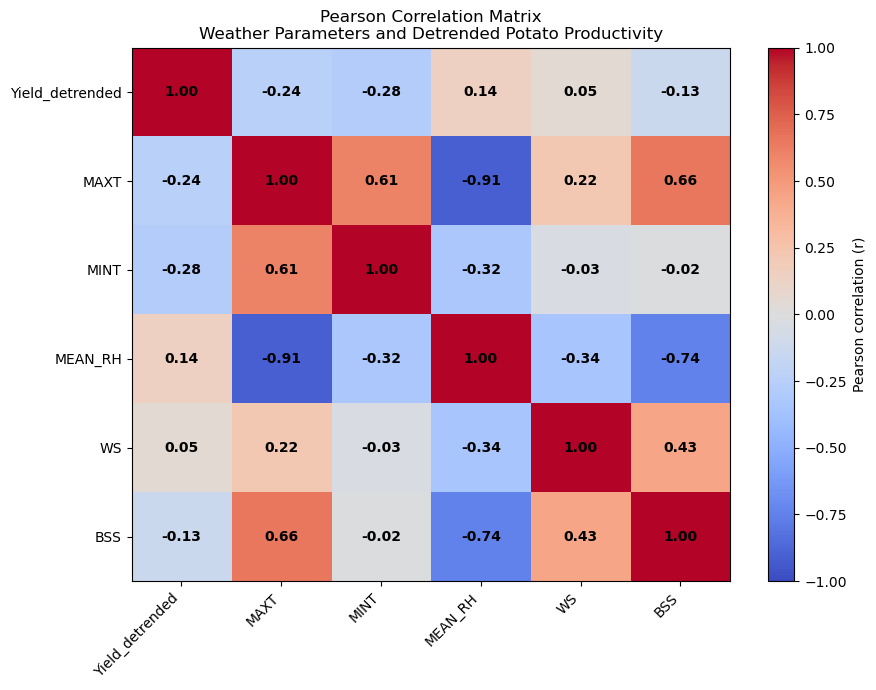

OBJECTIVE 3 — WEEK-WISE WEATHER–YIELD CORRELATION
Correlation target: DETRENDED POTATO PRODUCTIVITY


,Weather_Parameter,SMW,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Pearson_p_FDR,Significance,Absolute_r
0,MAXT,3,29,-0.343570,0.068031,-0.343350,0.068220,0.992548,NS,0.343570
1,MAXT,4,29,-0.333903,0.076689,-0.245320,0.199602,0.992548,NS,0.333903
2,BSS,43,29,-0.332987,0.077550,-0.234975,0.219827,0.992548,NS,0.332987
3,WS,42,29,-0.312529,0.098814,-0.287192,0.130897,0.992548,NS,0.312529
4,BSS,44,29,-0.299336,0.114685,-0.302956,0.110153,0.992548,NS,0.299336
5,MEAN_RH,44,29,0.295625,0.119471,0.082266,0.671384,0.992548,NS,0.295625
6,MINT,5,29,-0.290476,0.126357,-0.280788,0.140092,0.992548,NS,0.290476
7,MEAN_RH,46,29,0.288498,0.129076,0.127094,0.511190,0.992548,NS,0.288498
8,MAXT,44,29,-0.285702,0.132996,-0.144335,0.455062,0.992548,NS,0.285702
9,MEAN_RH,43,29,0.269340,0.157683,0.131034,0.498068,0.992548,NS,0.269340



Number of statistically significant parameter-week associations after FDR correction: 0


,Weather_Parameter,SMW,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Pearson_p_FDR,Significance,Absolute_r


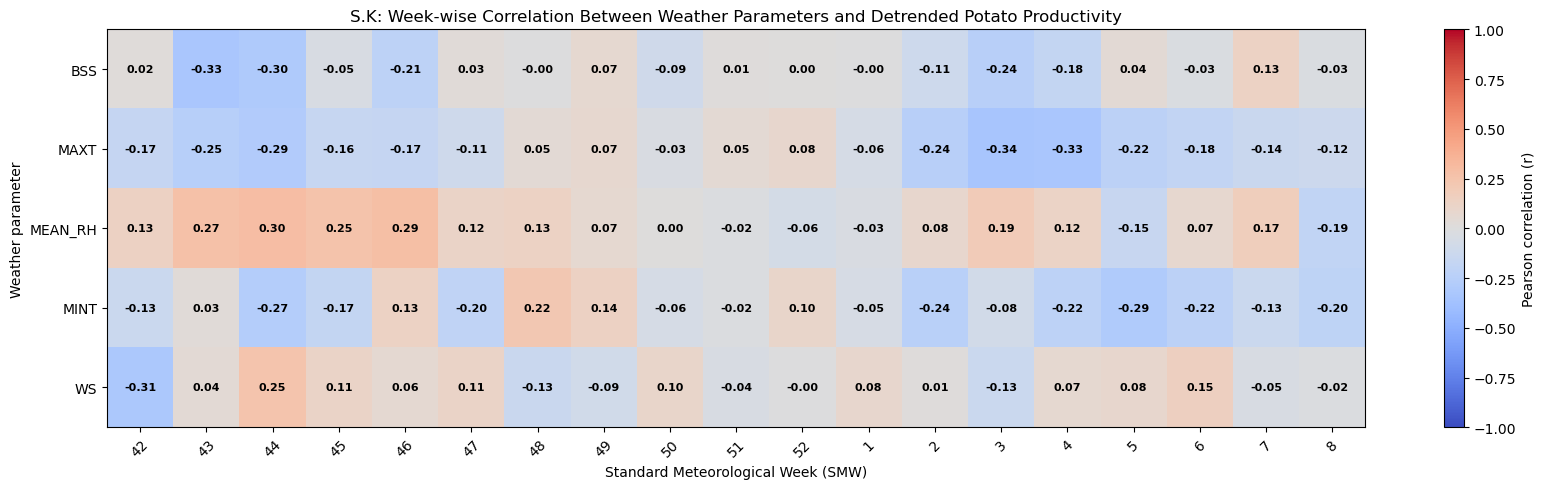


Strongest meteorological week for each weather parameter:


,Weather_Parameter,SMW,Pearson_r,Pearson_p,Pearson_p_FDR,Spearman_rho,Significance
0,BSS,43,-0.332987,0.077550,0.992548,-0.234975,NS
1,MAXT,3,-0.343570,0.068031,0.992548,-0.343350,NS
2,MEAN_RH,44,0.295625,0.119471,0.992548,0.082266,NS
3,MINT,5,-0.290476,0.126357,0.992548,-0.280788,NS
4,WS,42,-0.312529,0.098814,0.992548,-0.287192,NS



Influential meteorological weeks:


,SMW,Mean_Absolute_r,Maximum_Absolute_r,Significant_Associations
10,44,0.278975,0.299336,0
2,3,0.197374,0.343570,0
9,43,0.185478,0.332987,0
3,4,0.183115,0.333903,0
12,46,0.171870,0.288498,0
4,5,0.157775,0.290476,0
8,42,0.153488,0.312529,0
11,45,0.149764,0.253133,0
1,2,0.136851,0.244083,0
5,6,0.129835,0.220020,0


OBJECTIVE 4 — CROP GROWTH-STAGE WEATHER SENSITIVITY
Correlation target: DETRENDED POTATO PRODUCTIVITY


,Growth_Stage,Weather_Parameter,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Pearson_p_FDR,Significance,Absolute_r
21,Late_Bulking_Maturation,MINT,29,-0.294260,0.121269,-0.286700,0.131588,0.930026,NS,0.294260
15,Tuber_Bulking,MAXT,29,-0.286751,0.131516,-0.334975,0.075688,0.930026,NS,0.286751
2,Establishment_Early_Vegetative,MEAN_RH,29,0.247986,0.194605,0.040394,0.835194,0.930026,NS,0.247986
0,Establishment_Early_Vegetative,MAXT,29,-0.233541,0.222737,-0.048276,0.803606,0.930026,NS,0.233541
20,Late_Bulking_Maturation,MAXT,29,-0.230429,0.229139,-0.235961,0.217843,0.930026,NS,0.230429
4,Establishment_Early_Vegetative,BSS,29,-0.226587,0.237212,-0.177340,0.357405,0.930026,NS,0.226587
1,Establishment_Early_Vegetative,MINT,29,-0.212561,0.268278,-0.230542,0.228904,0.930026,NS,0.212561
16,Tuber_Bulking,MINT,29,-0.193959,0.313372,-0.266010,0.163084,0.930026,NS,0.193959
7,Vegetative_Stolon_Formation,MEAN_RH,29,0.184865,0.337033,0.029064,0.881032,0.930026,NS,0.184865
19,Tuber_Bulking,BSS,29,-0.172101,0.372010,-0.104926,0.588033,0.930026,NS,0.172101



Growth-stage sensitivity summary:


,Growth_Stage,Mean_Absolute_r,Maximum_Absolute_r,Mean_Absolute_Spearman,Significant_Associations,Number_of_Weather_Parameters
0,Establishment_Early_Vegetative,0.197823,0.247986,0.124926,0,5
1,Vegetative_Stolon_Formation,0.081947,0.184865,0.055961,0,5
2,Tuber_Initiation,0.015514,0.030821,0.073400,0,5
3,Tuber_Bulking,0.143793,0.286751,0.172611,0,5
4,Late_Bulking_Maturation,0.133701,0.294260,0.165123,0,5



No growth stage contains a statistically significant weather association after FDR correction.


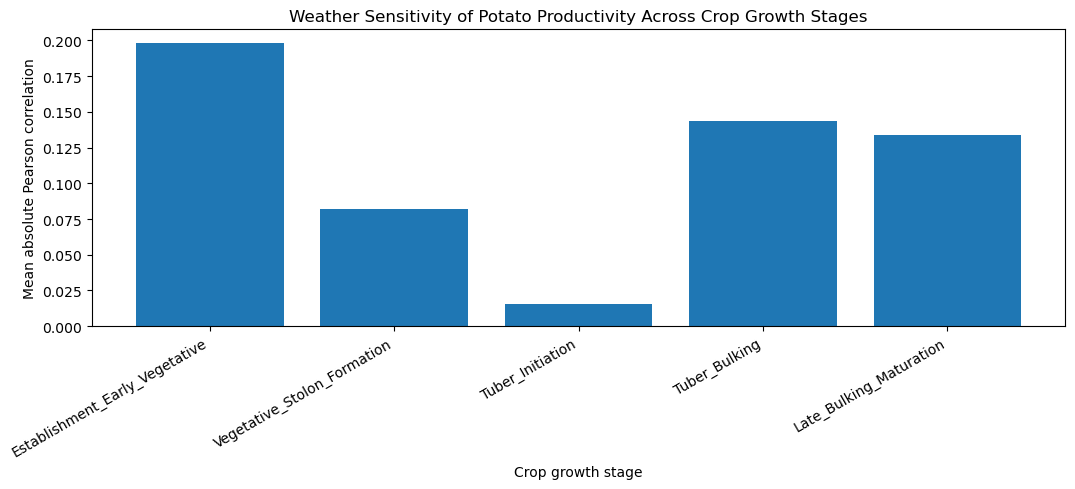


Objectives 2–4 and Objective 6 results exported successfully.


In [21]:
# ============================================================
# OBJECTIVES 2–4
# ROBUST WEATHER–YIELD CORRELATION ANALYSIS
# USING DETRENDED PRODUCTIVITY
# ============================================================

from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# IMPORTANT:
# Weather-yield correlation analyses use detrended productivity.
# The original Productivity column is NOT modified.
# ------------------------------------------------------------

CORRELATION_TARGET = "Yield_detrended"

if CORRELATION_TARGET not in data.columns:
    raise ValueError(
        "Yield_detrended was not found. "
        "Run the detrending section before this analysis."
    )

# Weather parameters available in the notebook
BASE_WEATHER_VARS = [
    "MAXT",
    "MINT",
    "MEAN_RH",
    "WS",
    "BSS",
    "RF"
]

AVAILABLE_WEATHER_VARS = [
    v for v in BASE_WEATHER_VARS
    if any(
        c.startswith(v + "_")
        for c in WEEKLY_FEATURES
    )
]

if not AVAILABLE_WEATHER_VARS:
    raise ValueError(
        "No weekly weather variables are available "
        "for correlation analysis."
    )

print("Correlation target:", CORRELATION_TARGET)
print(
    "Weather parameters:",
    AVAILABLE_WEATHER_VARS
)


# ============================================================
# SAFE CORRELATION FUNCTION
# ============================================================

def _safe_correlations(x, y):

    temp = pd.DataFrame({
        "x": x,
        "y": y
    }).replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    n = len(temp)

    if n < 3:
        return n, np.nan, np.nan, np.nan, np.nan

    if (
        temp["x"].nunique() < 2
        or temp["y"].nunique() < 2
    ):
        return n, np.nan, np.nan, np.nan, np.nan

    pearson_r, pearson_p = pearsonr(
        temp["x"],
        temp["y"]
    )

    spearman_rho, spearman_p = spearmanr(
        temp["x"],
        temp["y"]
    )

    return (
        n,
        pearson_r,
        pearson_p,
        spearman_rho,
        spearman_p
    )


# ============================================================
# SIGNIFICANCE LABEL FUNCTION
# ============================================================

def significance_label(p):

    if pd.isna(p):
        return "NS"

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return "NS"


# ============================================================
# OBJECTIVE 2
# SEASONAL WEATHER–YIELD RELATIONSHIP
# ============================================================

seasonal_values = pd.DataFrame({
    "Yield_detrended": pd.to_numeric(
        data[CORRELATION_TARGET],
        errors="coerce"
    )
})

for var in AVAILABLE_WEATHER_VARS:

    cols = [
        f"{var}_{week}"
        for week in SEASON_WEEKS
        if f"{var}_{week}" in data.columns
    ]

    if not cols:
        continue

    # Rainfall is accumulated across the season
    if var == "RF":

        seasonal_values[var] = data[
            cols
        ].sum(
            axis=1,
            min_count=1
        )

    # Other parameters are averaged across the season
    else:

        seasonal_values[var] = data[
            cols
        ].mean(
            axis=1
        )


# ------------------------------------------------------------
# Calculate seasonal correlations
# ------------------------------------------------------------

seasonal_results = []

for var in AVAILABLE_WEATHER_VARS:

    if var not in seasonal_values.columns:
        continue

    (
        n,
        r,
        p,
        rho,
        sp
    ) = _safe_correlations(
        seasonal_values[var],
        seasonal_values["Yield_detrended"]
    )

    seasonal_results.append({
        "Weather_Parameter": var,
        "N": n,
        "Pearson_r": r,
        "Pearson_p": p,
        "Spearman_rho": rho,
        "Spearman_p": sp
    })


seasonal_correlation = pd.DataFrame(
    seasonal_results
)


# ------------------------------------------------------------
# FDR correction
# ------------------------------------------------------------

seasonal_correlation["Pearson_p_FDR"] = np.nan

valid = seasonal_correlation[
    "Pearson_p"
].notna()

if valid.any():

    seasonal_correlation.loc[
        valid,
        "Pearson_p_FDR"
    ] = multipletests(
        seasonal_correlation.loc[
            valid,
            "Pearson_p"
        ],
        method="fdr_bh"
    )[1]


# ------------------------------------------------------------
# Significance
# ------------------------------------------------------------

seasonal_correlation["Significance"] = (
    seasonal_correlation[
        "Pearson_p_FDR"
    ].apply(significance_label)
)

seasonal_correlation["Absolute_Pearson_r"] = (
    seasonal_correlation[
        "Pearson_r"
    ].abs()
)

seasonal_correlation = (
    seasonal_correlation
    .sort_values(
        "Absolute_Pearson_r",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 90)
print(
    "OBJECTIVE 2 — SEASONAL WEATHER–YIELD CORRELATION"
)
print(
    "Correlation target: DETRENDED POTATO PRODUCTIVITY"
)
print("=" * 90)

display(seasonal_correlation)


# ------------------------------------------------------------
# Strongest statistically significant association
# ------------------------------------------------------------

significant_seasonal = seasonal_correlation[
    (
        seasonal_correlation[
            "Pearson_p_FDR"
        ] < 0.05
    )
    &
    seasonal_correlation[
        "Pearson_r"
    ].notna()
].copy()


if significant_seasonal.empty:

    print(
        "\nNo seasonal weather parameter was "
        "statistically significant after FDR correction."
    )

else:

    strongest = significant_seasonal.iloc[0]

    print(
        "\nStrongest statistically significant "
        "seasonal association:"
    )

    print(
        f"Weather parameter : "
        f"{strongest['Weather_Parameter']}"
    )

    print(
        f"Pearson r : "
        f"{strongest['Pearson_r']:.3f}"
    )

    print(
        f"Spearman rho : "
        f"{strongest['Spearman_rho']:.3f}"
    )

    print(
        f"FDR-adjusted p-value : "
        f"{strongest['Pearson_p_FDR']:.4f}"
    )


# ============================================================
# OBJECTIVE 6
# CORRELATION MATRIX WITH ACTUAL VALUES
# ============================================================

correlation_matrix = seasonal_values[
    ["Yield_detrended"] +
    AVAILABLE_WEATHER_VARS
].corr(
    method="pearson"
)

print("\nPearson correlation matrix:")
display(correlation_matrix)


# ------------------------------------------------------------
# Heatmap WITH numerical correlation values
# ------------------------------------------------------------

plt.figure(
    figsize=(
        max(9, len(correlation_matrix.columns) * 1.25),
        max(7, len(correlation_matrix.columns) * 1.05)
    )
)

im = plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    im,
    label="Pearson correlation (r)"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)


# ------------------------------------------------------------
# ADD NUMERICAL VALUES INSIDE EACH CELL
# ------------------------------------------------------------

for i in range(
    len(correlation_matrix.index)
):

    for j in range(
        len(correlation_matrix.columns)
    ):

        value = correlation_matrix.iloc[i, j]

        if pd.notna(value):

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold"
            )


plt.title(
    "Pearson Correlation Matrix\n"
    "Weather Parameters and Detrended Potato Productivity"
)

plt.tight_layout()
plt.show()


# ============================================================
# OBJECTIVE 3
# WEEK-WISE WEATHER–YIELD CORRELATION
# ============================================================

weekly_results = []

for var in AVAILABLE_WEATHER_VARS:

    for week in SEASON_WEEKS:

        feature = f"{var}_{week}"

        if feature not in data.columns:
            continue

        (
            n,
            r,
            p,
            rho,
            sp
        ) = _safe_correlations(
            data[feature],
            data[CORRELATION_TARGET]
        )

        weekly_results.append({
            "Weather_Parameter": var,
            "SMW": week,
            "N": n,
            "Pearson_r": r,
            "Pearson_p": p,
            "Spearman_rho": rho,
            "Spearman_p": sp
        })


weekly_correlation = pd.DataFrame(
    weekly_results
)


# ------------------------------------------------------------
# FDR correction across ALL parameter × week tests
# ------------------------------------------------------------

weekly_correlation[
    "Pearson_p_FDR"
] = np.nan

valid = weekly_correlation[
    "Pearson_p"
].notna()

if valid.any():

    weekly_correlation.loc[
        valid,
        "Pearson_p_FDR"
    ] = multipletests(
        weekly_correlation.loc[
            valid,
            "Pearson_p"
        ],
        method="fdr_bh"
    )[1]


weekly_correlation["Significance"] = (
    weekly_correlation[
        "Pearson_p_FDR"
    ].apply(significance_label)
)

weekly_correlation["Absolute_r"] = (
    weekly_correlation[
        "Pearson_r"
    ].abs()
)


weekly_correlation_ranked = (
    weekly_correlation
    .sort_values(
        "Absolute_r",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 90)
print(
    "OBJECTIVE 3 — WEEK-WISE WEATHER–YIELD CORRELATION"
)
print(
    "Correlation target: DETRENDED POTATO PRODUCTIVITY"
)
print("=" * 90)

display(
    weekly_correlation_ranked.head(20)
)


# ------------------------------------------------------------
# Significant parameter-week associations
# ------------------------------------------------------------

significant_weekly = weekly_correlation[
    (
        weekly_correlation[
            "Pearson_p_FDR"
        ] < 0.05
    )
    &
    weekly_correlation[
        "Pearson_r"
    ].notna()
].sort_values(
    "Absolute_r",
    ascending=False
)


print(
    f"\nNumber of statistically significant "
    f"parameter-week associations after FDR correction: "
    f"{len(significant_weekly)}"
)

display(significant_weekly)


# ============================================================
# WEEK-WISE CORRELATION HEATMAP WITH VALUES
# ============================================================

weekly_matrix = (
    weekly_correlation
    .pivot(
        index="Weather_Parameter",
        columns="SMW",
        values="Pearson_r"
    )
    .reindex(
        columns=SEASON_WEEKS
    )
)

plt.figure(
    figsize=(
        17,
        max(5, len(weekly_matrix) * 1.0)
    )
)

im = plt.imshow(
    weekly_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    im,
    label="Pearson correlation (r)"
)

plt.xticks(
    range(len(SEASON_WEEKS)),
    SEASON_WEEKS,
    rotation=45
)

plt.yticks(
    range(len(weekly_matrix.index)),
    weekly_matrix.index
)


# Add correlation values
for i in range(
    len(weekly_matrix.index)
):

    for j in range(
        len(weekly_matrix.columns)
    ):

        value = weekly_matrix.iloc[i, j]

        if pd.notna(value):

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold"
            )


plt.xlabel(
    "Standard Meteorological Week (SMW)"
)

plt.ylabel(
    "Weather parameter"
)

plt.title(
    "S.K: Week-wise Correlation Between Weather Parameters "
    "and Detrended Potato Productivity"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Strongest week for each parameter
# ------------------------------------------------------------

strongest_week_by_parameter = (
    weekly_correlation
    .dropna(
        subset=["Pearson_r"]
    )
    .loc[
        weekly_correlation
        .dropna(
            subset=["Pearson_r"]
        )
        .groupby(
            "Weather_Parameter"
        )["Absolute_r"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

print(
    "\nStrongest meteorological week for each weather parameter:"
)

display(
    strongest_week_by_parameter[
        [
            "Weather_Parameter",
            "SMW",
            "Pearson_r",
            "Pearson_p",
            "Pearson_p_FDR",
            "Spearman_rho",
            "Significance"
        ]
    ]
)


# ------------------------------------------------------------
# Overall influential meteorological weeks
# ------------------------------------------------------------

week_summary = (
    weekly_correlation
    .dropna(
        subset=["Pearson_r"]
    )
    .groupby("SMW")
    .agg(
        Mean_Absolute_r=(
            "Absolute_r",
            "mean"
        ),
        Maximum_Absolute_r=(
            "Absolute_r",
            "max"
        ),
        Significant_Associations=(
            "Pearson_p_FDR",
            lambda x: (
                x < 0.05
            ).sum()
        )
    )
    .reset_index()
    .sort_values(
        [
            "Significant_Associations",
            "Mean_Absolute_r"
        ],
        ascending=[
            False,
            False
        ]
    )
)

print(
    "\nInfluential meteorological weeks:"
)

display(
    week_summary
)



# ============================================================
# OBJECTIVE 4
# CROP GROWTH-STAGE SENSITIVITY
# ============================================================

STAGE_WEEKS = {

    "Establishment_Early_Vegetative":
        [42, 43, 44, 45],

    "Vegetative_Stolon_Formation":
        [46, 47, 48],

    "Tuber_Initiation":
        [49, 50, 51],

    "Tuber_Bulking":
        [52, 1, 2, 3, 4],

    "Late_Bulking_Maturation":
        [5, 6, 7, 8]
}


# ------------------------------------------------------------
# Check that every season week is assigned exactly once
# ------------------------------------------------------------

assigned_weeks = [
    week
    for weeks in STAGE_WEEKS.values()
    for week in weeks
]

if sorted(assigned_weeks) != sorted(SEASON_WEEKS):

    raise ValueError(
        "Growth-stage definitions do not exactly cover "
        "SMW 42–52 and SMW 1–8."
    )


# ------------------------------------------------------------
# Create stage-level weather variables
# ------------------------------------------------------------

stage_data = pd.DataFrame({

    "Yield_detrended":
        pd.to_numeric(
            data[CORRELATION_TARGET],
            errors="coerce"
        )
})


for stage, weeks in STAGE_WEEKS.items():

    for var in AVAILABLE_WEATHER_VARS:

        cols = [
            f"{var}_{week}"
            for week in weeks
            if f"{var}_{week}" in data.columns
        ]

        if not cols:
            continue

        feature_name = (
            f"{stage}__{var}"
        )

        if var == "RF":

            stage_data[feature_name] = (
                data[cols]
                .sum(
                    axis=1,
                    min_count=1
                )
            )

        else:

            stage_data[feature_name] = (
                data[cols]
                .mean(
                    axis=1
                )
            )


# ------------------------------------------------------------
# Stage-wise correlations
# ------------------------------------------------------------

stage_results = []

for stage in STAGE_WEEKS:

    for var in AVAILABLE_WEATHER_VARS:

        feature = (
            f"{stage}__{var}"
        )

        if feature not in stage_data.columns:
            continue

        (
            n,
            r,
            p,
            rho,
            sp
        ) = _safe_correlations(
            stage_data[feature],
            stage_data[
                "Yield_detrended"
            ]
        )

        stage_results.append({

            "Growth_Stage":
                stage,

            "Weather_Parameter":
                var,

            "N":
                n,

            "Pearson_r":
                r,

            "Pearson_p":
                p,

            "Spearman_rho":
                rho,

            "Spearman_p":
                sp
        })


stage_correlation = pd.DataFrame(
    stage_results
)


# ------------------------------------------------------------
# FDR correction
# ------------------------------------------------------------

stage_correlation[
    "Pearson_p_FDR"
] = np.nan

valid = stage_correlation[
    "Pearson_p"
].notna()

if valid.any():

    stage_correlation.loc[
        valid,
        "Pearson_p_FDR"
    ] = multipletests(
        stage_correlation.loc[
            valid,
            "Pearson_p"
        ],
        method="fdr_bh"
    )[1]


stage_correlation[
    "Significance"
] = (
    stage_correlation[
        "Pearson_p_FDR"
    ].apply(
        significance_label
    )
)

stage_correlation[
    "Absolute_r"
] = (
    stage_correlation[
        "Pearson_r"
    ].abs()
)


print("=" * 90)
print(
    "OBJECTIVE 4 — CROP GROWTH-STAGE WEATHER SENSITIVITY"
)
print(
    "Correlation target: DETRENDED POTATO PRODUCTIVITY"
)
print("=" * 90)

display(
    stage_correlation.sort_values(
        "Absolute_r",
        ascending=False
    )
)


# ------------------------------------------------------------
# Stage-level summary
# ------------------------------------------------------------

stage_summary = (
    stage_correlation
    .dropna(
        subset=["Pearson_r"]
    )
    .groupby(
        "Growth_Stage"
    )
    .agg(

        Mean_Absolute_r=(
            "Absolute_r",
            "mean"
        ),

        Maximum_Absolute_r=(
            "Absolute_r",
            "max"
        ),

        Mean_Absolute_Spearman=(
            "Spearman_rho",
            lambda x: x.abs().mean()
        ),

        Significant_Associations=(
            "Pearson_p_FDR",
            lambda x: (
                x < 0.05
            ).sum()
        ),

        Number_of_Weather_Parameters=(
            "Weather_Parameter",
            "count"
        )
    )
    .reset_index()
)


stage_summary["Stage_Order"] = (
    stage_summary[
        "Growth_Stage"
    ].map(
        {
            stage: i
            for i, stage
            in enumerate(
                STAGE_WEEKS
            )
        }
    )
)

stage_summary = (
    stage_summary
    .sort_values(
        "Stage_Order"
    )
    .drop(
        columns="Stage_Order"
    )
    .reset_index(drop=True)
)


print(
    "\nGrowth-stage sensitivity summary:"
)

display(
    stage_summary
)


# ------------------------------------------------------------
# Identify statistically supported sensitive stage
# ------------------------------------------------------------

significant_stages = (
    stage_summary[
        stage_summary[
            "Significant_Associations"
        ] > 0
    ]
    .copy()
)


if significant_stages.empty:

    print(
        "\nNo growth stage contains a "
        "statistically significant weather "
        "association after FDR correction."
    )

else:

    most_sensitive = (
        significant_stages
        .sort_values(
            [
                "Significant_Associations",
                "Mean_Absolute_r"
            ],
            ascending=[
                False,
                False
            ]
        )
        .iloc[0]
    )

    print(
        "\nGrowth stage with strongest "
        "statistical weather association:"
    )

    print(
        f"Stage: "
        f"{most_sensitive['Growth_Stage']}"
    )

    print(
        f"Mean |r|: "
        f"{most_sensitive['Mean_Absolute_r']:.3f}"
    )

    print(
        f"Significant associations: "
        f"{int(most_sensitive['Significant_Associations'])}"
    )


# ============================================================
# GROWTH-STAGE SENSITIVITY CHART
# ============================================================

plt.figure(
    figsize=(11, 5)
)

plt.bar(
    stage_summary[
        "Growth_Stage"
    ],
    stage_summary[
        "Mean_Absolute_r"
    ]
)

plt.xlabel(
    "Crop growth stage"
)

plt.ylabel(
    "Mean absolute Pearson correlation"
)

plt.title(
    "Weather Sensitivity of Potato Productivity "
    "Across Crop Growth Stages"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# EXPORT OBJECTIVES 2–4 RESULTS
# ============================================================

seasonal_correlation.to_csv(
    "objective_2_seasonal_weather_yield_correlation_detrended.csv",
    index=False
)

weekly_correlation.to_csv(
    "objective_3_weekwise_weather_yield_correlation_detrended.csv",
    index=False
)

weekly_correlation_ranked.to_csv(
    "objective_3_weekwise_ranked_associations_detrended.csv",
    index=False
)

week_summary.to_csv(
    "objective_3_influential_meteorological_weeks_detrended.csv",
    index=False
)

stage_correlation.to_csv(
    "objective_4_growth_stage_weather_correlation_detrended.csv",
    index=False
)

stage_summary.to_csv(
    "objective_4_growth_stage_sensitivity_summary_detrended.csv",
    index=False
)

correlation_matrix.to_csv(
    "objective_6_detrended_correlation_matrix.csv"
)

print(
    "\nObjectives 2–4 and Objective 6 results "
    "exported successfully."
)

## 12. Interpretation and methodological warning

The selected features are now determined **separately for each model**, rather than being copied from one global RFE/MI/SelectKBest result.

A model may still legitimately end up with the same method or even overlapping features as another model. That is possible when the data contain a strong common signal. What is no longer possible is for the code to force every model to use the exact same feature set simply because feature selection was performed once globally.

The reference image does not provide the original paper's exact K-selection rule or model-specific selector configuration, so this notebook should be described as a **reference-structure replication**, not an exact reproduction of the original numerical procedure.

Because Sabarkantha has only a small number of complete seasons, the selected weeks should be treated as exploratory/hypothesis-generating. Feature selection and imputation are now nested inside each LOOCV fold (no selection leakage). Note that choosing the best (method, K) per model from the nested scores still gives a mildly optimistic R², and the F-test significance stars in Section 14 do not account for that search, so treat them as indicative only; an independent validation period remains the strongest check.


## 13. Save all charts and result tables to `Final_Outputs`

This section re-creates every chart already produced above (the inline backend closes each
figure once it is shown, so figures must be redrawn to be saved) and writes them, together
with every results table, into a single `Final_Outputs` folder (with `Charts/` and `Tables/`
subfolders). It also adds a handful of extra charts that make the model results easier to
read at a glance: a model leaderboard, an RMSE/MAE comparison, a Pseudo-AIC comparison, a
feature-selection-method reliability boxplot, a predicted-vs-actual scatter for the best
model, and a residuals-over-time plot for the best model.

In [22]:
# 18. Save all charts and result tables to "Final_Outputs"

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FINAL_DIR = "Final_Outputs"
CHART_DIR = os.path.join(FINAL_DIR, "Charts")
TABLE_DIR = os.path.join(FINAL_DIR, "Tables")
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)


def save_fig(fig, name):
    path = os.path.join(CHART_DIR, name + ".png")
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("Saved chart:", path)


def save_table(df, name, index=False):
    csv_path = os.path.join(TABLE_DIR, name + ".csv")
    xlsx_path = os.path.join(TABLE_DIR, name + ".xlsx")
    df.to_csv(csv_path, index=index)
    df.to_excel(xlsx_path, index=index)
    print("Saved table:", csv_path, "&", xlsx_path)


# ------------------------------------------------------------
# 18.1  Re-save every results table produced earlier
# ------------------------------------------------------------
save_table(district_summary, "01_district_productivity_ranking")
save_table(seasonal_correlation, "02_seasonal_weather_yield_correlation")
save_table(weekly_correlation, "03_weekwise_weather_yield_correlation")
save_table(weekly_correlation_ranked, "03b_weekwise_ranked_associations")
save_table(week_summary, "03c_influential_meteorological_weeks")
save_table(stage_correlation, "04_growth_stage_weather_correlation")
save_table(stage_summary, "04b_growth_stage_sensitivity_summary")
save_table(correlation_matrix, "06_correlation_matrix", index=True)
save_table(trials_df, "07_feature_selection_model_trials")
save_table(final_table, "08_final_model_comparison")
save_table(selected_feature_table, "09_selected_features_by_model")

# ------------------------------------------------------------
# 18.2  Re-draw and save every chart already shown in the notebook
#       (the inline backend closes figures after display, so they
#       are rebuilt here from the data that is still in memory)
# ------------------------------------------------------------

# --- Objective 1: district ranking ---
fig = plt.figure(figsize=(11, max(6, len(district_summary) * 0.35)))
plt.barh(district_summary["District"], district_summary["Mean_Productivity_MT_ha"], color="#4C72B0")
plt.xlabel("Mean potato productivity (MT/ha)")
plt.ylabel("District")
plt.title("Gujarat districts ranked by mean potato productivity")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "01_district_productivity_ranking")

# --- Objective 2/6: correlation matrix heatmap (detrended target) ---
fig = plt.figure(figsize=(max(9, len(correlation_matrix.columns) * 1.25),
                           max(7, len(correlation_matrix.columns) * 1.05)))
im = plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, label="Pearson correlation (r)")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        v = correlation_matrix.iloc[i, j]
        if pd.notna(v):
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=10, fontweight="bold")
plt.title("Pearson Correlation Matrix\nWeather Parameters vs Detrended Potato Productivity")
plt.tight_layout()
save_fig(fig, "02_seasonal_correlation_matrix")

# --- Objective 3: week-wise correlation heatmap ---
fig = plt.figure(figsize=(17, max(5, len(weekly_matrix) * 1.0)))
im = plt.imshow(weekly_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, label="Pearson correlation (r)")
plt.xticks(range(len(SEASON_WEEKS)), SEASON_WEEKS, rotation=45)
plt.yticks(range(len(weekly_matrix.index)), weekly_matrix.index)
for i in range(len(weekly_matrix.index)):
    for j in range(len(weekly_matrix.columns)):
        v = weekly_matrix.iloc[i, j]
        if pd.notna(v):
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, fontweight="bold")
plt.xlabel("Standard Meteorological Week (SMW)")
plt.ylabel("Weather parameter")
plt.title("S.K: Week-wise Correlation Between Weather Parameters and Detrended Potato Productivity")
plt.tight_layout()
save_fig(fig, "03_weekwise_correlation_heatmap")

# --- Objective 3: influential-week strength line plot ---
plot_week = week_summary.sort_values("SMW")
fig = plt.figure(figsize=(14, 5))
plt.plot(plot_week["SMW"], plot_week["Mean_Absolute_r"], marker="o", label="Mean |Pearson r|")
plt.plot(plot_week["SMW"], plot_week["Maximum_Absolute_r"], marker="s", label="Maximum |Pearson r|")
plt.xlabel("Standard Meteorological Week (SMW)")
plt.ylabel("Absolute correlation")
plt.title("Weather-potato yield association strength by meteorological week")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_fig(fig, "03b_influential_weeks_trend")

# --- Objective 4: growth-stage sensitivity ---
fig = plt.figure(figsize=(11, 5))
plt.bar(stage_summary["Growth_Stage"], stage_summary["Mean_Absolute_r"], color="#55A868")
plt.xlabel("Crop growth stage")
plt.ylabel("Mean absolute Pearson correlation")
plt.title("Weather Sensitivity of Potato Productivity Across Crop Growth Stages")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_fig(fig, "04_growth_stage_sensitivity")

# --- Actual vs predicted, all models ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data["StartYear"], y, "o-", label="Observed productivity", color="black", linewidth=2)
for r in results:
    pred = r["loocv_pred_resid"] + trend
    ax.plot(data["StartYear"], pred, "--", label=f"{r['model']} ({r['fs_method']})")
ax.set_xlabel("Crop year (start year)")
ax.set_ylabel("Productivity (MT/ha)")
ax.set_title("Sabarkantha potato productivity - LOOCV trend-restored predictions")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_fig(fig, "10_actual_vs_predicted_all_models")

# ------------------------------------------------------------
# 18.3  NEW charts that show the model results more clearly
# ------------------------------------------------------------

# (a) Model leaderboard - R2 ranked, lollipop style (easier to compare than a plain bar chart)
lb = final_table.sort_values("R2", ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hlines(lb["Model"], 0, lb["R2"], color="#4C72B0", linewidth=2)
ax.plot(lb["R2"], lb["Model"], "o", color="#C44E52", markersize=9)
for x, ymod in zip(lb["R2"], lb["Model"]):
    ax.text(x + 0.01, ymod, f"{x:.2f}", va="center", fontsize=9)
ax.set_xlabel("LOOCV R2 (trend-restored)")
ax.set_title("Model leaderboard - Sabarkantha potato yield models")
ax.set_xlim(0, max(1.0, lb["R2"].max() * 1.15))
plt.tight_layout()
save_fig(fig, "11_model_leaderboard_r2")

# (b) Grouped bar: RMSE & MAE per model (same units -> directly comparable)
fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(final_table))
width = 0.35
ax.bar(xpos - width / 2, final_table["RMSE"], width, label="RMSE", color="#4C72B0")
ax.bar(xpos + width / 2, final_table["MAE"], width, label="MAE", color="#DD8452")
ax.set_xticks(xpos)
ax.set_xticklabels(final_table["Model"], rotation=30, ha="right")
ax.set_ylabel("Error (MT/ha)")
ax.set_title("Model error comparison - RMSE vs MAE (lower is better)")
ax.legend()
plt.tight_layout()
save_fig(fig, "12_model_rmse_mae_comparison")

# (c) Pseudo-AIC per model (lower is better)
order = final_table.sort_values("Pseudo-AIC")
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(order["Model"], order["Pseudo-AIC"], color="#8172B2")
ax.set_ylabel("Pseudo-AIC (lower is better)")
ax.set_title("Model comparison by Pseudo-AIC")
ax.set_xticklabels(order["Model"], rotation=30, ha="right")
plt.tight_layout()
save_fig(fig, "13_model_pseudo_aic_comparison")

# (d) Feature-selection method reliability - LOOCV R2 across all trials, by method
fig, ax = plt.subplots(figsize=(9, 5))
methods = trials_df["Feature Selection Method"].unique()
box_data = [trials_df.loc[trials_df["Feature Selection Method"] == m, "LOOCV_R2_residual"] for m in methods]
ax.boxplot(box_data, labels=methods, showmeans=True)
ax.set_ylabel("LOOCV R2 (residual target)")
ax.set_title("Feature-selection method reliability across all models/K")
plt.tight_layout()
save_fig(fig, "14_feature_selection_method_reliability")

# (e) Predicted vs Actual scatter (1:1 line) for the best model
best_row = final_table.loc[final_table["R2"].idxmax()]
best_result = next(r for r in results if r["model"] == best_row["Model"])
best_pred = best_result["loocv_pred_resid"] + trend
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, best_pred, color="#4C72B0", s=60, zorder=3)
lims = [min(y.min(), best_pred.min()) * 0.97, max(y.max(), best_pred.max()) * 1.03]
ax.plot(lims, lims, "--", color="gray", label="1:1 line")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual productivity (MT/ha)")
ax.set_ylabel("Predicted productivity (MT/ha)")
ax.set_title(f"Predicted vs Actual - Best model: {best_row['Model']} (R2={best_row['R2']:.2f})")
ax.legend()
plt.tight_layout()
save_fig(fig, "15_best_model_predicted_vs_actual")

# (f) Residuals of the best model over time
residuals = y.values - best_pred
fig, ax = plt.subplots(figsize=(10, 4))
ax.axhline(0, color="gray", linestyle="--")
ax.bar(data["StartYear"], residuals, color=np.where(residuals >= 0, "#55A868", "#C44E52"))
ax.set_xlabel("Crop year (start year)")
ax.set_ylabel("Residual (Actual - Predicted, MT/ha)")
ax.set_title(f"Residuals over time - Best model: {best_row['Model']}")
plt.tight_layout()
save_fig(fig, "16_best_model_residuals")

print("\nAll charts and tables saved under:", os.path.abspath(FINAL_DIR))

Saved table: Final_Outputs\Tables\01_district_productivity_ranking.csv & Final_Outputs\Tables\01_district_productivity_ranking.xlsx
Saved table: Final_Outputs\Tables\02_seasonal_weather_yield_correlation.csv & Final_Outputs\Tables\02_seasonal_weather_yield_correlation.xlsx
Saved table: Final_Outputs\Tables\03_weekwise_weather_yield_correlation.csv & Final_Outputs\Tables\03_weekwise_weather_yield_correlation.xlsx
Saved table: Final_Outputs\Tables\03b_weekwise_ranked_associations.csv & Final_Outputs\Tables\03b_weekwise_ranked_associations.xlsx
Saved table: Final_Outputs\Tables\03c_influential_meteorological_weeks.csv & Final_Outputs\Tables\03c_influential_meteorological_weeks.xlsx
Saved table: Final_Outputs\Tables\04_growth_stage_weather_correlation.csv & Final_Outputs\Tables\04_growth_stage_weather_correlation.xlsx
Saved table: Final_Outputs\Tables\04b_growth_stage_sensitivity_summary.csv & Final_Outputs\Tables\04b_growth_stage_sensitivity_summary.xlsx
Saved table: Final_Outputs\Tables\

C:\Users\DSSON\AppData\Local\Temp\ipykernel_2588\712971723.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order["Model"], rotation=30, ha="right")
C:\Users\DSSON\AppData\Local\Temp\ipykernel_2588\712971723.py:175: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=methods, showmeans=True)


Saved chart: Final_Outputs\Charts\14_feature_selection_method_reliability.png
Saved chart: Final_Outputs\Charts\15_best_model_predicted_vs_actual.png
Saved chart: Final_Outputs\Charts\16_best_model_residuals.png

All charts and tables saved under: C:\Users\DSSON\Documents\M.Sc. Sem 2\AAU\Project_02\Code_Script\Final_Outputs


## 14. Reference-style Potato model-comparison matrix

Builds the same style of table as the reference screenshot (Model, crop, feature-selection
method and the weather-parameter/week features grouped like `BSS (12, 36)`), but for the
Sabarkantha **Potato** results, with **MAE added** and the metric columns
(`R²`, `AIC`, `RMSE`, `MAE`) moved to the end, `MAE` last. It is saved as a nicely formatted
Excel file, a CSV, and a quick-look PNG image of the table, all inside `Final_Outputs`.

In [23]:
# 19. Reference-style Potato model-comparison matrix
#     (same layout family as the supplied reference screenshot, adapted to Potato + MAE,
#      with R2 / Significance / AIC / RMSE / MAE placed last and MAE at the very end)

from collections import OrderedDict
from scipy.stats import f as f_dist
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from openpyxl.utils import get_column_letter


def model_r2_significance(r2, n, k):
    """Overall F-test for the significance of a model's R² (Fisher's test of the
    significance of a multiple correlation coefficient):

        F = (R2 / k) / ((1 - R2) / (n - k - 1)),  F ~ F(k, n-k-1) under H0: population R2 = 0

    n = number of crop seasons used to fit/evaluate the model, k = number of
    selected weather features for that model (the 'K' column). Returns '**' if
    p <= 0.01, '*' if p <= 0.05, otherwise '' (not significant / not testable).
    """
    if pd.isna(r2) or pd.isna(k) or k <= 0:
        return ""
    dof1 = int(k)
    dof2 = n - dof1 - 1
    if dof2 <= 0 or r2 <= 0 or r2 >= 1:
        return ""
    F_stat = (r2 / dof1) / ((1 - r2) / dof2)
    p_val = f_dist.sf(F_stat, dof1, dof2)
    if p_val <= 0.01:
        return "**"
    elif p_val <= 0.05:
        return "*"
    return ""


# n = number of crop seasons used throughout modelling (same n as R2/RMSE/MAE above)
N_SEASONS = len(y)
model_significance = final_table.apply(
    lambda row: model_r2_significance(row["R2"], N_SEASONS, row["K"]), axis=1
)


def format_selected_features(feat_str):
    """Turn 'BSS_12, RF_27, WS_6, WS_7, WS_8, WS_35, MINT_36, MEAN_RH_12' into
    'BSS (12, 36)\nRF (27)\nWS (6, 7, 8, 35)\nMINT (36)\nMEAN RH (12)' -
    i.e. one weather parameter per line with its selected weeks, like the reference table."""
    groups = OrderedDict()
    for tok in [t.strip() for t in str(feat_str).split(",") if t.strip()]:
        parts = tok.rsplit("_", 1)
        if len(parts) == 2 and parts[1].isdigit():
            param, week = parts
        else:
            param, week = tok, None
        param_disp = param.replace("_", " ")
        groups.setdefault(param_disp, [])
        if week is not None:
            groups[param_disp].append(int(week))
    lines = []
    for param, weeks in groups.items():
        if weeks:
            weeks_sorted = sorted(set(weeks))
            lines.append(f"{param} ({', '.join(str(w) for w in weeks_sorted)})")
        else:
            lines.append(param)
    return "\n".join(lines)


potato_reference_table = final_table.copy()
potato_reference_table.insert(1, "Crop", "Potato")
potato_reference_table["Significance"] = model_significance
potato_reference_table["Selected Features"] = potato_reference_table["Selected Features"].apply(
    format_selected_features
)
potato_reference_table = potato_reference_table.rename(
    columns={"Pseudo-AIC": "AIC", "R2": "R2 "}
)  # trailing space keeps a distinct, ordered column name before renaming to R² below

# final column order: Model, Crop, Feature Selection, Selected Features, R2, Significance, AIC, RMSE, MAE (MAE last)
potato_reference_table = potato_reference_table[
    ["Model", "Crop", "Feature Selection", "Selected Features", "R2 ", "Significance", "AIC", "RMSE", "MAE"]
].rename(columns={"R2 ": "R\u00b2"})

display(potato_reference_table)


def save_formatted_excel(df, path):
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        df.to_excel(writer, index=False, sheet_name="Potato Results")
        ws = writer.sheets["Potato Results"]
        thin = Side(style="thin", color="000000")
        border = Border(left=thin, right=thin, top=thin, bottom=thin)
        header_fill = PatternFill("solid", fgColor="D9D9D9")

        for col_idx in range(1, len(df.columns) + 1):
            cell = ws.cell(row=1, column=col_idx)
            cell.font = Font(bold=True)
            cell.alignment = Alignment(wrap_text=True, vertical="center", horizontal="center")
            cell.fill = header_fill
            cell.border = border

        for row_idx in range(2, len(df) + 2):
            max_lines = 1
            for col_idx in range(1, len(df.columns) + 1):
                cell = ws.cell(row=row_idx, column=col_idx)
                cell.alignment = Alignment(wrap_text=True, vertical="top", horizontal="left")
                cell.border = border
                val = str(cell.value) if cell.value is not None else ""
                max_lines = max(max_lines, val.count("\n") + 1)
            ws.row_dimensions[row_idx].height = 15 * max_lines

        col_widths = [22, 10, 20, 42, 9, 12, 9, 9, 9]
        for i, w in enumerate(col_widths[: len(df.columns)], start=1):
            ws.column_dimensions[get_column_letter(i)].width = w

        footnote_row = len(df) + 3
        ws.cell(
            row=footnote_row, column=1,
            value="**R\u00b2 significant at the 0.01 level, *R\u00b2 significant at the 0.05 level "
                  "(overall F-test of model R\u00b2; blank = not statistically significant)."
        ).font = Font(italic=True, size=9)

    print("Saved formatted table:", path)


xlsx_path = os.path.join(TABLE_DIR, "17_potato_model_comparison_reference_style.xlsx")
csv_path = os.path.join(TABLE_DIR, "17_potato_model_comparison_reference_style.csv")
save_formatted_excel(potato_reference_table, xlsx_path)
potato_reference_table.to_csv(csv_path, index=False)
print("Saved table:", csv_path)
print("**R\u00b2 significant at 0.01 level, *R\u00b2 significant at 0.05 level "
      "(overall F-test of model R\u00b2).")


# Quick-look PNG of the table (mirrors the reference screenshot's look)
max_lines = max(str(v).count("\n") + 1 for v in potato_reference_table.values.flatten())
fig_height = 1 + len(potato_reference_table) * 0.42 * max_lines
fig, ax = plt.subplots(figsize=(16, fig_height))
ax.axis("off")
tbl = ax.table(
    cellText=potato_reference_table.values,
    colLabels=potato_reference_table.columns,
    cellLoc="left",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.0 * max_lines)
for (row, col), cell in tbl.get_celld().items():
    cell.set_text_props(ha="left", va="top")
    if row == 0:
        cell.set_text_props(fontweight="bold", ha="center", va="center")
        cell.set_facecolor("#D9D9D9")
fig.suptitle(
    "**R\u00b2 significant at the 0.01 level, *R\u00b2 significant at the 0.05 level "
    "(overall F-test of model R\u00b2)",
    y=0.02, fontsize=9, style="italic"
)
fig.tight_layout()
png_path = os.path.join(CHART_DIR, "17_potato_model_comparison_reference_style.png")
fig.savefig(png_path, dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved table image:", png_path)

,Model,Crop,Feature Selection,Selected Features,R²,Significance,AIC,RMSE,MAE
0,Stepwise Linear Regression,Potato,Mutual Information,"MAXT (48)\nMEAN RH (49)\nMINT (8, 48)\nBSS (44)",0.645,**,61.50,2.971,2.215
1,Random Forest,Potato,Mutual Information,"MAXT (48)\nMEAN RH (49)\nMINT (8, 48)\nBSS (44)",0.727,**,13.53,2.605,1.868
2,XGBoost,Potato,Mutual Information,"MAXT (48)\nMEAN RH (49)\nMINT (8, 48)\nBSS (44)",0.708,**,-126.07,2.697,1.960
3,SVR,Potato,Mutual Information,"MAXT (43, 48)\nMEAN RH (49)\nMINT (8, 45, 48)\...",0.793,**,-29.13,2.270,1.815
4,KNN,Potato,Mutual Information,"MAXT (48)\nMEAN RH (49)\nMINT (8, 48)",0.758,**,46.93,2.454,1.804
5,ANN (MLP),Potato,Mutual Information,"MAXT (43, 48)\nMEAN RH (49)\nMINT (8, 45, 48)\...",0.330,,-439.70,4.083,3.027


Saved formatted table: Final_Outputs\Tables\17_potato_model_comparison_reference_style.xlsx
Saved table: Final_Outputs\Tables\17_potato_model_comparison_reference_style.csv
**R² significant at 0.01 level, *R² significant at 0.05 level (overall F-test of model R²).
Saved table image: Final_Outputs\Charts\17_potato_model_comparison_reference_style.png


## 15. Weather-parameter correlation & significance table (reference style)

Reproduces the second style of table shown in the reference screenshot - one row per
parameter, a `Correlation` column, and a `Significance` column. The significance stars
(`**` = p<=0.01, `*` = p<=0.05) use the raw (unadjusted) Pearson p-value, matching the
reference table's own convention, and the cell shows `ns` (not significant) instead of
being left blank. A separate `Significance (FDR-adjusted)` column also reports the more
conservative Benjamini-Hochberg-corrected verdict for the six weather parameters, so both
the simple per-parameter test and the multiple-testing-corrected result are available.

In [24]:
# 20. Weather-parameter correlation & significance table
#     (reference-screenshot style: Parameter | Correlation | Significance)
#
#     IMPROVED:
#     - Uses the raw (unadjusted) two-tailed Pearson p-value for the '**' / '*' stars,
#       matching the convention used by the reference table (a simple per-parameter
#       significance test, not a multiple-testing correction).
#     - Shows 'ns' instead of a BLANK cell when a parameter is not significant, so the
#       column never looks empty/broken - it always has a value.
#     - Adds N (sample size), the exact p-value, and an FDR-adjusted verdict as extra
#       columns so it's clear *why* a parameter is or isn't starred, and so the more
#       conservative FDR-adjusted result stays available too.

PARAM_DISPLAY_NAMES = {
    "MAXT": "Maximum Temperature (\u00b0C)",
    "MINT": "Minimum Temperature (\u00b0C)",
    "MEAN_RH": "Mean Relative Humidity (%)",
    "BSS": "Bright Sunshine Hours",
    "WS": "Wind Speed",
    "RF": "Rainfall (mm)",
}


def significance_stars(p):
    """'**' if p<=0.01, '*' if p<=0.05, otherwise 'ns' (never blank)."""
    if pd.isna(p):
        return "n/a"
    if p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    return "ns"


potato_correlation_significance_table = seasonal_correlation[
    ["Weather_Parameter", "N", "Pearson_r", "Pearson_p", "Pearson_p_FDR"]
].copy()

potato_correlation_significance_table["Weather Parameter"] = (
    potato_correlation_significance_table["Weather_Parameter"].map(PARAM_DISPLAY_NAMES)
    .fillna(potato_correlation_significance_table["Weather_Parameter"])
)
potato_correlation_significance_table["Correlation"] = potato_correlation_significance_table[
    "Pearson_r"
].round(3)
potato_correlation_significance_table["p-value"] = potato_correlation_significance_table[
    "Pearson_p"
].round(4)
potato_correlation_significance_table["Significance"] = potato_correlation_significance_table[
    "Pearson_p"
].apply(significance_stars)
potato_correlation_significance_table["Significance (FDR-adjusted)"] = (
    potato_correlation_significance_table["Pearson_p_FDR"].apply(significance_stars)
)

potato_correlation_significance_table = potato_correlation_significance_table[
    ["Weather Parameter", "Correlation", "Significance", "Significance (FDR-adjusted)", "p-value", "N"]
].sort_values("Correlation", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

display(potato_correlation_significance_table)

n_sig_raw = (potato_correlation_significance_table["Significance"] != "ns").sum()
if n_sig_raw == 0:
    print(
        "\nNote: none of the weather parameters are statistically significant at the "
        "0.05 level (raw p-value) against detrended potato yield with this sample size. "
        "This reflects genuinely weak correlations (|r| well below the critical r needed "
        "for significance at this N) - it is a real result, not a code error. Consider "
        "reporting this as 'no individually significant seasonal weather driver was "
        "identified' rather than forcing stars onto the table."
    )

# --- Save as CSV / formatted Excel ---
corr_xlsx_path = os.path.join(TABLE_DIR, "18_potato_weather_correlation_significance.xlsx")
corr_csv_path = os.path.join(TABLE_DIR, "18_potato_weather_correlation_significance.csv")

with pd.ExcelWriter(corr_xlsx_path, engine="openpyxl") as writer:
    potato_correlation_significance_table.to_excel(writer, index=False, sheet_name="Correlation")
    ws = writer.sheets["Correlation"]
    thin = Side(style="thin", color="000000")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    header_fill = PatternFill("solid", fgColor="D9D9D9")

    n_cols = len(potato_correlation_significance_table.columns)
    for col_idx in range(1, n_cols + 1):
        cell = ws.cell(row=1, column=col_idx)
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.fill = header_fill
        cell.border = border

    for row_idx in range(2, len(potato_correlation_significance_table) + 2):
        for col_idx in range(1, n_cols + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            cell.border = border
            cell.alignment = Alignment(
                horizontal="left" if col_idx == 1 else "center", vertical="center"
            )

    col_widths = [30, 12, 12, 22, 10, 6]
    for i, w in enumerate(col_widths[:n_cols], start=1):
        ws.column_dimensions[get_column_letter(i)].width = w

    footnote_row = len(potato_correlation_significance_table) + 3
    ws.cell(
        row=footnote_row, column=1,
        value="**Significant at the 0.01 level, *significant at the 0.05 level, "
              "ns = not significant (raw two-tailed p-value). The 'Significance "
              "(FDR-adjusted)' column applies the Benjamini-Hochberg correction "
              "for testing 6 parameters at once and is the more conservative result."
    ).font = Font(italic=True, size=9)

potato_correlation_significance_table.to_csv(corr_csv_path, index=False)
print("Saved table:", corr_xlsx_path, "&", corr_csv_path)

# --- Quick-look PNG (mirrors the reference screenshot's look) ---
fig, ax = plt.subplots(figsize=(10, 1 + len(potato_correlation_significance_table) * 0.5))
ax.axis("off")
tbl = ax.table(
    cellText=potato_correlation_significance_table.values,
    colLabels=potato_correlation_significance_table.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.2)
for (row, col), cell in tbl.get_celld().items():
    cell.set_text_props(ha="left" if col == 0 else "center")
    if row == 0:
        cell.set_text_props(fontweight="bold", ha="center")
        cell.set_facecolor("#D9D9D9")
fig.suptitle(
    "**p<=0.01, *p<=0.05, ns = not significant (raw p-value); "
    "'Significance (FDR-adjusted)' is the Benjamini-Hochberg-corrected verdict",
    y=0.02, fontsize=8, style="italic"
)
fig.tight_layout()
corr_png_path = os.path.join(CHART_DIR, "18_potato_weather_correlation_significance.png")
fig.savefig(corr_png_path, dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved table image:", corr_png_path)

,Weather Parameter,Correlation,Significance,Significance (FDR-adjusted),p-value,N
0,Minimum Temperature (°C),-0.276,ns,ns,0.1470,29
1,Maximum Temperature (°C),-0.236,ns,ns,0.2172,29
2,Mean Relative Humidity (%),0.144,ns,ns,0.4554,29
3,Bright Sunshine Hours,-0.133,ns,ns,0.4927,29
4,Wind Speed,0.049,ns,ns,0.8020,29



Note: none of the weather parameters are statistically significant at the 0.05 level (raw p-value) against detrended potato yield with this sample size. This reflects genuinely weak correlations (|r| well below the critical r needed for significance at this N) - it is a real result, not a code error. Consider reporting this as 'no individually significant seasonal weather driver was identified' rather than forcing stars onto the table.
Saved table: Final_Outputs\Tables\18_potato_weather_correlation_significance.xlsx & Final_Outputs\Tables\18_potato_weather_correlation_significance.csv
Saved table image: Final_Outputs\Charts\18_potato_weather_correlation_significance.png
